<h1 style="color: White; font-weight: 800;">Capstone 1</h1>

<h2 style="color: blue; font-weight: 800;">
  Index : 
</h2>

<div class="nb-index">
  <ol>
    <li>
      <a href="#data-cleaning">Data Cleaning and Data Pre-processing</a>
      <ol>
        <li><a href="#importing-modules">Importing Modules</a></li>
        <li><a href="#data-ingestion">Data Ingestion</a></li>
        <li><a href="#column-name-meaning">Column Name Meaning</a></li>
        <li><a href="#column-name-changing">Column Name Changing</a></li>
        <li><a href="#category-columns">Category Columns</a></li>
        <li><a href="#binary-values-columns">Binary Values Columns</a></li>
        <li><a href="#numerical-columns">Numerical Columns</a></li>
        <li><a href="#null-value-treatment">NULL Values Treatment</a></li>
      </ol>
    </li>
      <li>
          <a href="#eda-eda">EDA (Exploratory Data Analysis)</a>
          <ol>
              <li><a href="#moving-status-to-end">Moving Status column to end of DataFrame</a></li>
              <li><a href="#outlier-treatment">Outlier Treatment</a></li>
              <li><a href="#date-time">Treatment of Date_of_Interview Column</a></li>
              <li><a href="#numerical-plots">Distribution Plots of Numerical Columns</a></li>
          </ol>
      </li>
  </ol>
</div>

 <a id="data-cleaning"></a>

<h1 style="color: red; font-weight: 800;">Data Cleaning and Data Pre-processing</h1>

 <a id="importing-modules"></a>

<h2 style="color: green; font-weight: 800;">Importing Modules</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
#first copied all files in my working directory
#checking all files are present or not
import os

files = [
    "HR_Hiring_details_transaction.csv",
    "Joining_Status.csv",
    "Location_Master.xlsx",
    "LOB_Master.csv",
    "Domicile_Master.xlsx",
    "Region_Location_Mapping.xlsx",
    "Region_Master.xlsx",
    "Postal_Code_Master.xlsx",
    "Interview_Dates.xlsx"
]

for file_name in files:
    print(file_name, "->", os.path.exists(file_name))

HR_Hiring_details_transaction.csv -> True
Joining_Status.csv -> True
Location_Master.xlsx -> True
LOB_Master.csv -> True
Domicile_Master.xlsx -> True
Region_Location_Mapping.xlsx -> True
Region_Master.xlsx -> True
Postal_Code_Master.xlsx -> True
Interview_Dates.xlsx -> True


In [6]:
def smart_read_excel(filepath):
    """Try reading as Excel (openpyxl), fall back to CSV if format is unrecognized."""
    try:
        return pd.read_excel(filepath, engine="openpyxl")
    except ValueError:
        print(f"[Warning] '{filepath}' is not a valid Excel file. Trying CSV fallback...")
        try:
            return pd.read_csv(filepath, encoding="utf-8-sig")
        except Exception as e:
            raise ValueError(f"Could not load '{filepath}' as Excel or CSV. Error: {e}")

# Loading files
hiring    = pd.read_csv("HR_Hiring_details_transaction.csv", encoding="utf-8-sig")
status    = pd.read_csv("Joining_Status.csv", encoding="utf-8-sig")
location  = pd.read_excel("Location_Master.xlsx",         engine="openpyxl")
lob       = pd.read_csv("LOB_Master.csv",                 encoding="utf-8-sig")
domicile  = pd.read_excel("Domicile_Master.xlsx",         engine="openpyxl")
region_map = pd.read_excel("Region_Location_Mapping.xlsx", engine="openpyxl")
region    = smart_read_excel("Region_Master.xlsx")   # <-- uses safe loader

print("Loaded successfully")

Loaded successfully


In [7]:
#checking the datas
tables = {
    "hiring": hiring,
    "status": status,
    "location": location,
    "lob": lob,
    "domicile": domicile,
    "region_map": region_map,
    "region": region
}

for name, table in tables.items():
    print("\n", name)
    print(table.columns.tolist())
    display(table.head(2))



 hiring
['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id']


,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Rex_in_Yrs,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,L001,201301,34.0,1,D6
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,L002,600020,34.0,2,D9



 status
['Candidate_Ref', 'Status']


,Candidate_Ref,Status
0,2110407,Joined
1,2112635,Joined



 location
['Location_ID', 'Location']


...

,Domicile_ID,Domicile_Name
0,D1,Andhra Pradesh
1,D2,Bihar



 region_map
['Region_ID', 'Location_ID']


,Region_ID,Location_ID
0,R1,L001
1,R2,L002



 region
['Region_ID', 'Region_Name']


,Region_ID,Region_Name
0,R1,North
1,R2,South


In [8]:
# Joins

def clean_key(series):
    return (
        series.astype("string")
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )

for table in [hiring, status, location, lob, domicile, region_map, region]:
    table.columns = table.columns.astype(str).str.strip()

hiring   = hiring.rename(columns={"LOB_ID": "LOB_Id", "Domicile_ID": "Domicile_Id"})
domicile = domicile.rename(columns={"Domicile_ID": "Domicile_Id"})

for table, column in [
    (hiring,      "Candidate_Ref"),
    (status,      "Candidate_Ref"),
    (hiring,      "Location_ID"),
    (location,    "Location_ID"),
    (region_map,  "Location_ID"),
    (hiring,      "LOB_Id"),
    (lob,         "LOB_Id"),
    (hiring,      "Domicile_Id"),
    (domicile,    "Domicile_Id"),
    (region_map,  "Region_ID"),
    (region,      "Region_ID")
]:
    if column in table.columns:
        table[column] = clean_key(table[column])

status = status.drop_duplicates(subset=["Candidate_Ref"])

df = hiring.merge(status[["Candidate_Ref", "Status"]],       on="Candidate_Ref", how="left")
df = df.merge(location[["Location_ID", "Location"]],         on="Location_ID",   how="left")
df = df.merge(lob[["LOB_Id", "LOB"]],                        on="LOB_Id",        how="left")
df = df.merge(domicile[["Domicile_Id", "Domicile_Name"]],    on="Domicile_Id",   how="left")
df = df.merge(region_map[["Region_ID", "Location_ID"]],      on="Location_ID",   how="left")
df = df.merge(region[["Region_ID", "Region_Name"]],          on="Region_ID",     how="left")

df["Status_Clean"] = df["Status"].astype("string").str.strip().str.title()
df["Joined_Flag"]  = df["Status_Clean"].eq("Joined")

analysis = df[df["Status_Clean"].notna()].drop_duplicates(subset=["Candidate_Ref"]).copy()

for col in [
    "Duration_to_accept_offer",
    "Notice_Period",
    "Percent_hike_expected_in_CTC",
    "Percent_hike_offered_in_CTC",
    "Percent_difference_CTC",
    "Rex_in_Yrs",
    "Age"
]:
    if col in analysis.columns:
        analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

# Save joined table
analysis.to_csv("HR_Hiring_details_transaction_joined.csv", index=False, encoding="utf-8-sig")

print("Merged rows:", analysis.shape[0])
print("Saved as: HR_Hiring_details_transaction_joined.csv")
display(analysis.head())

Merged rows: 8995
Saved as: HR_Hiring_details_transaction_joined.csv


,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,LOB_Id,Domicile_Id,Status,Location,LOB,Domicile_Name,Region_ID,Region_Name,Status_Clean,Joined_Flag
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,...,1,D6,Joined,Noida,ERS,Goa,R1,North,Joined,True
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,...,2,D9,Joined,Chennai,INFRA,Himachal Pradesh,R2,South,Joined,True
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,2,D10,Joined,Noida,INFRA,Jharkhand,R1,North,Joined,True
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,2,D3,Joined,Noida,INFRA,Chandigarh,R1,North,Joined,True
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,2,D21,Joined,Noida,INFRA,Tripura,R1,North,Joined,True


<a id="data-ingestion"></a>

<h2 style="color: green; font-weight: 800;">Data Ingestion</h2>

In [2]:
df = pd.read_csv("HR_Hiring_details_transaction_joined.csv")

data = pd.DataFrame(df)
# Remove accidental spaces from column names
data.columns = data.columns.str.strip()

# Convert updated column names to the names used in your existing code
column_mapping = {
    "CANDIDATE_REF": "Candidate_Ref",
    "DOJ_EXTENDED": "DOJ_Extended",
    "DURATION_TO_ACCEPT_OFFER": "Duration_to_accept_offer",
    "NOTICE_PERIOD": "Notice_Period",
    "OFFERED_BAND": "Offered_Band",
    "PERCENT_HIKE_EXPECTED_IN_CTC": "Percent_hike_expected_in_CTC",
    "PERCENT_HIKE_OFFERED_IN_CTC": "Percent_hike_offered_in_CTC",
    "PERCENT_DIFFERENCE_CTC": "Percent_difference_CTC",
    "JOINING_BONUS": "Joining_Bonus",
    "CANDIDATE_RELOCATE_ACTUAL": "Candidate_relocate_actual",
    "GENDER": "Gender",
    "CANDIDATE_SOURCE": "Candidate_Source",
    "REX_IN_YRS": "Rex_in_Yrs",
    "LOCATION_ID": "Location_ID",
    "POSTAL_CODE": "Postal_Code",
    "AGE": "Age",
    "LOB_ID": "LOB_Id",
    "DOMICILE_ID": "Domicile_Id",
    "JOINING_STATUS": "Status",
    "DATE_OF_INTERVIEW": "Date_of_Interview",
    "LOB_NAME": "LOB",
    "DOMICILE_NAME": "Domicile_Name",
    "LOCATION_NAME": "Location_Name",
    "REGION_ID": "Region_Id",
    "REGION_NAME": "Region_Name"
}

data.rename(columns=column_mapping, inplace=True)

# Add Sno if it is not present in the updated file
if "Sno" not in data.columns:
    data.insert(0, "Sno", range(1, len(data) + 1))

# Verify the final column names
print(data.columns.tolist())

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [3]:
# df = pd.read_csv("HR_Hiring_details_transaction.csv")
# df
# data = pd.DataFrame(df)


In [4]:
data

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


In [5]:
cols = list(data.columns)
print(cols)

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [6]:
row,column = data.shape
print(f"No of Rows : {row}\nNo of Columns = {column}")

No of Rows : 8995
No of Columns = 26


In [7]:
data.head()

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North


In [8]:
data.sample(10)

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
2531,2532,2386504,Yes,99,30,E1,51.52,51.52,0.00,No,...,27.0,4,D24,Joined,2013-11-07,BFSI,West Bengal,Gurgaon,R1,North
6412,6413,3263582,Yes,51,45,E2,27.99,27.99,0.00,No,...,32.0,2,D21,Joined,2013-10-23,INFRA,Tripura,Chennai,R2,South
4215,4216,2598439,Yes,98,60,E1,45.57,45.57,0.00,No,...,28.0,1,D9,Joined,2014-07-01,ERS,Himachal Pradesh,Noida,R1,North
8889,8890,3707763,No,23,30,E1,87.50,66.67,-20.83,No,...,34.0,1,D10,Joined,2013-07-18,ERS,Jharkhand,Pune,R4,West
7924,7925,3429949,Yes,49,30,E1,69.05,66.67,-2.38,No,...,34.0,8,D19,Joined,2013-01-19,EAS,Tamil Nadu,Bangalore,R2,South
950,951,2209120,Yes,17,30,E1,3.45,3.45,0.00,No,...,28.0,2,D7,Joined,2013-03-10,INFRA,Gujarat,Noida,R1,North
3379,3380,2474149,No,0,30,E2,63.64,63.64,0.00,No,...,24.0,2,D21,Joined,2014-01-06,INFRA,Tripura,Noida,R1,North
7886,7887,3424543,No,7,30,E1,14.17,14.17,0.00,Yes,...,34.0,3,D14,Joined,2013-01-05,Healthcare,Maharashtra,Noida,R1,North
1848,1849,2344555,No,22,30,E1,28.57,25.00,-3.57,No,...,26.0,1,D14,Joined,2013-07-03,ERS,Maharashtra,Chennai,R2,South
771,772,2188617,Yes,6,30,E3,0.00,-3.13,-3.13,No,...,39.0,2,D14,Joined,2013-03-03,INFRA,Maharashtra,Noida,R1,North


<a id="column-name-meaning"></a>

<h2 style="color: green; font-weight: 800;">Column Name Meaning</h2>

1.
*`CANDIDATE_REF`*
Unique reference number assigned to the candidate


2.
*`DOJ_EXTENDED`*
Indicates whether the candidate’s date of joining was extended


3.
*`DURATION_TO_ACCEPT_OFFER`*
Number of days taken by the candidate to accept the offer


4.
*`NOTICE_PERIOD`*
Notice period, generally measured in days, required by the candidate’s previous employer


5.
*`OFFERED_BAND`*
Job grade or employment level offered to the candidate


6.
*`PERCENT_HIKE_EXPECTED_IN_CTC`*
Percentage increase in CTC expected by the candidate


7.
*`PERCENT_HIKE_OFFERED_IN_CTC`*
Percentage increase in CTC offered by the organization


8.
*`PERCENT_DIFFERENCE_CTC`*
Percentage gap between the expected CTC hike and the offered CTC hike


9.
*`JOINING_BONUS`*
Indicates whether a joining bonus was offered


10.
*`CANDIDATE_RELOCATE_ACTUAL`*
Indicates whether relocation was required or accepted by the candidate


11.
*`GENDER`*
Gender of the candidate


12.
*`CANDIDATE_SOURCE`*
Recruitment source through which the candidate was identified or approached


13.
*`REX_IN_YRS`*
Relevant or related work experience in years


14.
*`LOCATION_ID`*
Unique code representing the job or organization location


15.
*`POSTAL_CODE`*
Postal code associated with the job or organization location


16.
*`AGE`*
Age of the candidate


17.
*`LOB_ID`*
Unique code representing the candidate’s Line of Business or department


18.
*`DOMICILE_ID`*
Unique code representing the candidate’s home state or residential location


19.
*`JOINING_STATUS`*
Outcome of the offer, such as joined, not joined, or declined


20.
*`DATE_OF_INTERVIEW`*
Date on which the candidate interview was conducted


22.
*`LOB_NAME`*
Name of the candidate’s Line of Business or department


23.
*`DOMICILE_NAME`*
Name of the candidate’s home state or residential location


24.
*`LOCATION_NAME`*
Name of the job or organization location


4.
*`REGION_ID`*
Unique code representing the region


25.
*`REGION_NAME`*
Name of the region associated with the location

<a id="column-name-changing"></a>

<h2 style="color: green; font-weight: 800;">Column Name Changing</h2>

`Changing columns' name to more relatable name`

1. *Candidate_Ref* = **Candidate_ID**
2. *Duration_to_accept_offer* = **Acceptance_days**
3. *Percent_hike_expected_in_CTC* = **Expected_CTC_hike_pct**
4. *Percent_hike_offered_in_CTC* = **Offered_CTC_hike_pct**
5. *Percent_difference_CTC* = **CTC_diff_pct**
6. *Rex_in_Yrs* = **Experience_years**


In [9]:
data.rename(columns = {"Candidate_Ref" : "Candidate_ID", "Duration_to_accept_offer" : "Acceptance_days"
                      ,"Percent_hike_expected_in_CTC" : "Expected_CTC_hike_pct", "Percent_hike_offered_in_CTC" : "Offered_CTC_hike_pct",
                      "Percent_difference_CTC" : "CTC_diff_pct", "Rex_in_Yrs" : "Experience_years"}, inplace=True)

data.head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North


In [10]:
cols = list(data.columns)
print(f"Columns = {cols}")

Columns = ['Sno', 'Candidate_ID', 'DOJ_Extended', 'Acceptance_days', 'Notice_Period', 'Offered_Band', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Experience_years', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


<a id="category-columns"></a>

<h2 style="color: green; font-weight: 800;">Category Columns</h2>

`nan value only in Offered_Band`

In [11]:
category_cols = list(data.select_dtypes(exclude='number').columns)
print(f"Category columns = {category_cols}")

Category columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [12]:
for col in category_cols:
    print(f"Value counts of {col} : {data[col].value_counts()}\n")
# There is Null values in ->
# 1.Offered_Band
# 2.Location_ID

Value counts of DOJ_Extended : DOJ_Extended
No     4788
Yes    4207
Name: count, dtype: int64

Value counts of Offered_Band : Offered_Band
E1              5565
E2              2704
E3               502
E0               211
Not Assigned      13
Name: count, dtype: int64

Value counts of Joining_Bonus : Joining_Bonus
No     8578
Yes     417
Name: count, dtype: int64

Value counts of Candidate_relocate_actual : Candidate_relocate_actual
No     7705
Yes    1290
Name: count, dtype: int64

Value counts of Gender : Gender
Male      7444
Female    1551
Name: count, dtype: int64

Value counts of Candidate_Source : Candidate_Source
Direct               4801
Agency               2585
Employee Referral    1609
Name: count, dtype: int64

Value counts of Location_ID : Location_ID
L002    3150
L001    2727
L004    2230
L005     341
L009     197
L003     146
L006     129
L008      48
Null      13
L007       8
L010       6
Name: count, dtype: int64

Value counts of Domicile_Id : Domicile_Id
D8     402


<a id="binary-values-columns"></a>

<h2 style="color: green; font-weight: 800;">Binary Values Columns</h2>

`There is no inconsistency as there is only 'Yes' or 'No' or 'Male' or 'Female'`

- Binary Columns are -
1. DOJ_Extended
2. Joining_Bonus
3. Gender
4. Candidate_relocate_actual
5. Status

In [13]:
data['DOJ_Extended'].value_counts()

DOJ_Extended
No     4788
Yes    4207
Name: count, dtype: int64

In [14]:
data['Joining_Bonus'].value_counts()

Joining_Bonus
No     8578
Yes     417
Name: count, dtype: int64

In [15]:
data['Gender'].value_counts()

Gender
Male      7444
Female    1551
Name: count, dtype: int64

In [16]:
data['Status'].value_counts()

Status
Joined        7313
Not Joined    1682
Name: count, dtype: int64

In [17]:
data['Candidate_relocate_actual'].value_counts()

Candidate_relocate_actual
No     7705
Yes    1290
Name: count, dtype: int64

### There is no inconsistency or ambiguity in Binary Columns

<a id="numerical-columns"></a>

<h2 style="color: green; font-weight: 800;">Numerical Columns</h2>


In [18]:
numerical_cols = list(data.select_dtypes(include = 'number').columns)
print(f"Numerical columns = {numerical_cols}")

Numerical columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


In [19]:
data[numerical_cols].describe()

,Sno,Candidate_ID,Acceptance_days,Notice_Period,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Experience_years,Postal_Code,Age,LOB_Id
count,8995.000000,8.995000e+03,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8980.000000,8995.000000
mean,4498.000000,2.843647e+06,21.434464,39.291829,43.864804,40.657356,-3.207447,4.239022,453494.479266,29.912027,3.113063
std,2596.777169,4.863448e+05,25.811616,22.220239,29.788975,36.064060,27.412448,2.547571,180254.661181,4.095699,2.125902
min,1.000000,2.109586e+06,0.000000,0.000000,-68.830000,-60.530000,-200.000000,0.000000,122107.000000,20.000000,1.000000
25%,2249.500000,2.386476e+06,3.000000,30.000000,27.270000,22.090000,-12.755000,3.000000,201301.000000,27.000000,1.000000
50%,4498.000000,2.807482e+06,10.000000,30.000000,40.000000,36.000000,0.000000,4.000000,560034.000000,29.000000,2.000000
75%,6746.500000,3.300060e+06,33.000000,60.000000,53.850000,50.000000,0.000000,6.000000,600020.000000,34.000000,4.000000
max,8995.000000,3.836076e+06,224.000000,120.000000,359.770000,471.430000,385.720000,24.000000,700027.000000,60.000000,9.000000


In [20]:
data[numerical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sno                    8995 non-null   int64  
 1   Candidate_ID           8995 non-null   int64  
 2   Acceptance_days        8995 non-null   int64  
 3   Notice_Period          8995 non-null   int64  
 4   Expected_CTC_hike_pct  8995 non-null   float64
 5   Offered_CTC_hike_pct   8995 non-null   float64
 6   CTC_diff_pct           8995 non-null   float64
 7   Experience_years       8995 non-null   int64  
 8   Postal_Code            8995 non-null   int64  
 9   Age                    8980 non-null   float64
 10  LOB_Id                 8995 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 773.1 KB


### Checking for NULL values

In [21]:
data[numerical_cols].isna().sum()

# There is NULL values in ->
# 1. Age 

Sno                       0
Candidate_ID              0
Acceptance_days           0
Notice_Period             0
Expected_CTC_hike_pct     0
Offered_CTC_hike_pct      0
CTC_diff_pct              0
Experience_years          0
Postal_Code               0
Age                      15
LOB_Id                    0
dtype: int64

In [22]:
data['Age'].isna().sum()

np.int64(15)

In [23]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

### Checking for duplicate values

In [24]:
data[numerical_cols].duplicated().sum()
# There is no duplicate value in numerical columns

np.int64(0)

`Columns to check further - Either will change data type or remove in EDA`

- Postal_Code
- LOB_Id

In [25]:
data['Postal_Code'].unique()

array([201301, 600020, 122107, 560034, 500004, 700027, 682001, 411002,
       600018, 400001, 560002, 382460, 560063, 500045, 411006])

In [26]:
data['LOB_Id'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [27]:
data['Notice_Period'].unique()
# Have to deep it as numeric (Imp)

array([ 30,  45, 120,   0,  75,  60,  90])

In [28]:
data['Acceptance_days'].unique()
# There is no negative(-) value, so this column is not imbalance.

array([ 14,  18,   3,  26,   1,  17,  37,  16,   6, 120,  44,   7,  98,
         0,  83,  32,  19,   4,  38,  24,  10,  53,   5,  46,   2,  31,
        54,  33, 105,  69,  68,  84,  28, 126, 106,  90,  21,  36,  34,
        20,  13,   8,  42,  12, 103,  43,  60,  23,  67,  15,  45,  25,
        47,  11,  48,  74,  30,  40,  35,  58,  29,  86,  51,  50,  39,
        57,  93,  55,  71,  56,  66,  62,   9,  64, 107,  27,  78,  22,
        49,  92,  61,  79,  77, 108,  70,  82, 210,  80,  97,  41,  59,
        88,  99,  63, 111,  87,  95,  52,  96,  91, 101,  65, 140,  76,
        73, 123, 104,  72, 117, 109,  89, 127,  81,  85,  75, 118, 114,
       110, 129, 124, 116, 181,  94, 121, 119, 102, 113, 115, 125, 131,
       100, 130, 224, 143, 122, 163])

In [29]:
print(data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0])
# There are many rows that have offered ctc hike percentage in negative value.
# So this negative values are important, because candidates with negative value of percentage ctc hike might not join the firm
print(f"\nNo of rows with negative(-) offered ctc hike percentage = {data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0].count()}")

7      -20.00
8      -22.22
10     -60.53
15     -27.31
29      -2.17
        ...  
8872   -17.04
8882    -6.67
8958    -2.86
8967   -10.00
8977   -14.29
Name: Offered_CTC_hike_pct, Length: 446, dtype: float64

No of rows with negative(-) offered ctc hike percentage = 446


<a id="null-value-treatment"></a>

<h2 style="color: green; font-weight: 800;">NULL Values Treatment</h2>

`Columns with NULL values :`

1. Age
2. Offered_Band
3. Location_ID
4. Location_Name                
5. Region_Id                    
6. Region_Name 

In [30]:
data.isna().sum()

# One thing here -> 
# The Data type of Location_ID is object, but its showing 0 null value here. That means there is NULL value as Object.

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                          15
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sno                        8995 non-null   int64  
 1   Candidate_ID               8995 non-null   int64  
 2   DOJ_Extended               8995 non-null   object 
 3   Acceptance_days            8995 non-null   int64  
 4   Notice_Period              8995 non-null   int64  
 5   Offered_Band               8995 non-null   object 
 6   Expected_CTC_hike_pct      8995 non-null   float64
 7   Offered_CTC_hike_pct       8995 non-null   float64
 8   CTC_diff_pct               8995 non-null   float64
 9   Joining_Bonus              8995 non-null   object 
 10  Candidate_relocate_actual  8995 non-null   object 
 11  Gender                     8995 non-null   object 
 12  Candidate_Source           8995 non-null   object 
 13  Experience_years           8995 non-null   int64

## Treatment of `Age` column

In [32]:
data['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
8980 non-null   float64
dtypes: float64(1)
memory usage: 70.4 KB


In [33]:
data['Age']

0       34.0
1       34.0
2       27.0
3       34.0
4       34.0
        ... 
8990    34.0
8991    34.0
8992    34.0
8993    34.0
8994    34.0
Name: Age, Length: 8995, dtype: float64

In [34]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

In [35]:
Age_missing = int(data['Age'].isna().sum())
Age_min = data['Age'].min()
Age_max = data['Age'].max()

Age_median = data['Age'].median()
Age_mean = data['Age'].mean()

print(f"Null values in Age column = {Age_missing}")
print(f"Min Age = {Age_min}")
print(f"Max Age = {Age_max}")
print(f"Median Age = {Age_median}")
print(f"Mean Age = {Age_mean}")

Null values in Age column = 15
Min Age = 20.0
Max Age = 60.0
Median Age = 29.0
Mean Age = 29.912026726057906


In [36]:
data['Age'][data["Age"] > Age_mean].count()

np.int64(4481)

In [37]:
data['Age'][data["Age"] <= Age_mean].count()

np.int64(4499)

In [38]:
data['Age'][data["Age"] > 35].count()

np.int64(435)

In [39]:
data['Age'][data["Age"] > 40].count()

np.int64(77)

In [40]:
data['Age'][data["Age"] > 50].count()

np.int64(2)

### Diagram of Age column distribution

In [41]:
age_count = pd.DataFrame(data['Age'].dropna().value_counts())
age_count

,count
Age,
34.0,2142
27.0,903
26.0,839
28.0,770
25.0,676
29.0,630
30.0,575
31.0,485
24.0,397


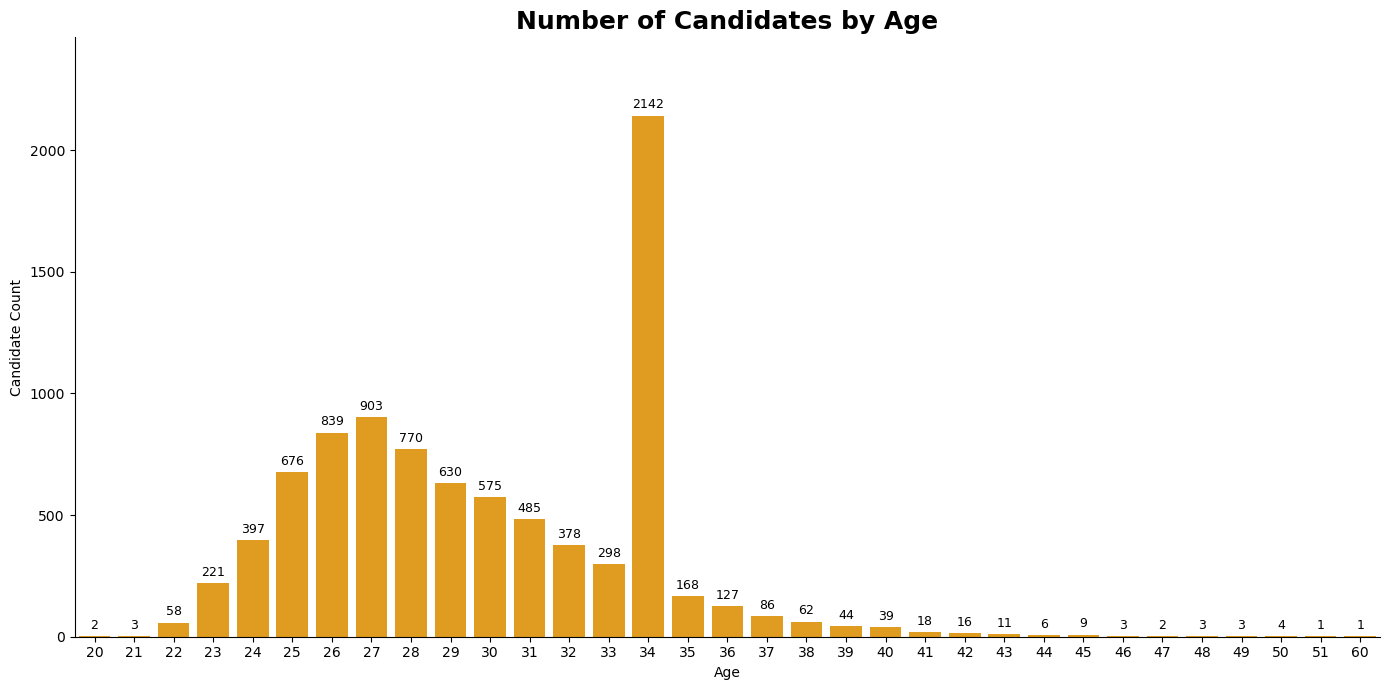

In [42]:
age_count2 = (
    data["Age"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

x = age_count2.index.tolist()
y = age_count2.tolist()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=x,
    y=y,
    color="orange"
)

ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.title("Number of Candidates by Age", fontsize=18, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Candidate Count")
plt.ylim(0, max(y) * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

### Outliers check for `Age` column

In [43]:
age = pd.to_numeric(data["Age"].dropna())

# Calculate IQR
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = age[(age < lower_bound) | (age > upper_bound)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values : {outliers.unique()}")

Q1: 27.0
Q3: 34.0
IQR: 7.0
Lower bound: 16.5
Upper bound: 44.5
Number of outliers: 26
Outlier values : [50. 45. 46. 49. 47. 48. 60. 51.]


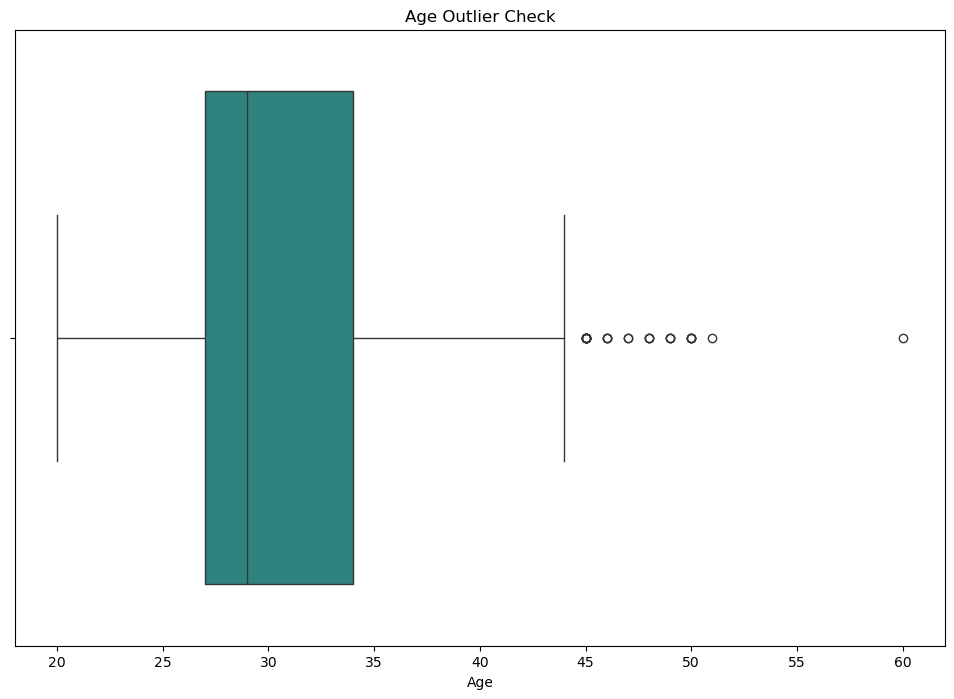

In [44]:
plt.figure(figsize=(12,8))

sns.boxplot(x=data["Age"].dropna(), palette='viridis')

plt.title("Age Outlier Check")
plt.xlabel("Age")
plt.show()

The decreasing number of candidates at higher ages indicates that the distribution is concentrated around younger ages and has a right tail. The mean age is approximately 29.91, while the median is 29. The IQR method flags ages above 44.5 as statistical outliers.
Because the higher ages can pull the mean upward, the median is the safer replacement value for the 15 missing ages. It represents the typical candidate more robustly and results in an actual whole-number age.

In [45]:
data[data['Age'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
397,398,2117861,Yes,62,60,E2,40.85,40.85,0.00,No,...,NaN,2,D15,Joined,2013-10-26,INFRA,Manipur,Noida,R1,North
406,407,2118480,No,4,30,E1,89.66,48.28,-41.38,No,...,NaN,5,D12,Joined,2014-03-30,CSMP,Kerala,Noida,R1,North
414,415,2119541,Yes,2,0,E2,56.86,37.25,-19.61,No,...,NaN,2,D15,Joined,2014-04-08,INFRA,Manipur,Noida,R1,North
425,426,2121112,No,3,30,Not Assigned,0.00,-6.45,-6.45,No,...,NaN,2,D4,Joined,2014-04-25,INFRA,Chhattisgarh,Bangalore,R2,South
446,447,2128251,No,58,30,E2,50.33,50.33,0.00,No,...,NaN,2,D24,Joined,2014-05-20,INFRA,West Bengal,Chennai,R2,South
485,486,2143765,Yes,41,90,E1,10.77,10.77,0.00,No,...,NaN,4,D7,Joined,2014-07-06,BFSI,Gujarat,Chennai,R2,South
526,527,2151137,No,4,45,E3,20.83,20.83,0.00,No,...,NaN,2,D23,Joined,2014-04-13,INFRA,Uttarkhand,Noida,R1,North
573,574,2160044,No,0,0,E2,17.78,14.31,-3.47,Yes,...,NaN,2,D13,Joined,2014-06-19,INFRA,Madhya Pradesh,Gurgaon,R1,North
616,617,2167868,No,5,30,E1,20.00,-4.00,-24.00,No,...,NaN,2,D13,Joined,2013-01-02,INFRA,Madhya Pradesh,Noida,R1,North
674,675,2177940,No,0,30,E1,13.46,34.56,21.10,No,...,NaN,5,D22,Joined,2013-01-22,CSMP,Uttar Pradesh,Gurgaon,R1,North


### Filling NULL values in `Age` column with `Median`

In [46]:
data['Age'].fillna(Age_median, inplace=True)

In [47]:
data['Age'].isna().sum()

np.int64(0)

In [48]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

## Treatment of `Offered_Band` column

In [49]:
data['Offered_Band'].replace("Not Assigned" , np.nan, inplace = True)

In [50]:
data['Offered_Band']

0       E2
1       E2
2       E2
3       E2
4       E2
        ..
8990    E1
8991    E1
8992    E2
8993    E1
8994    E1
Name: Offered_Band, Length: 8995, dtype: object

In [51]:
data['Offered_Band'].unique()

array(['E2', 'E1', 'E3', nan, 'E0'], dtype=object)

In [52]:
data['Offered_Band'].value_counts()

Offered_Band
E1    5565
E2    2704
E3     502
E0     211
Name: count, dtype: int64

In [53]:
data['Offered_Band'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Offered_Band
Non-Null Count  Dtype 
--------------  ----- 
8982 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [54]:
#print(f"No of NULL values in Offered_Band column = {data['Offered_Band'].isna().sum()}")
data['Offered_Band'].isna().sum()

np.int64(13)

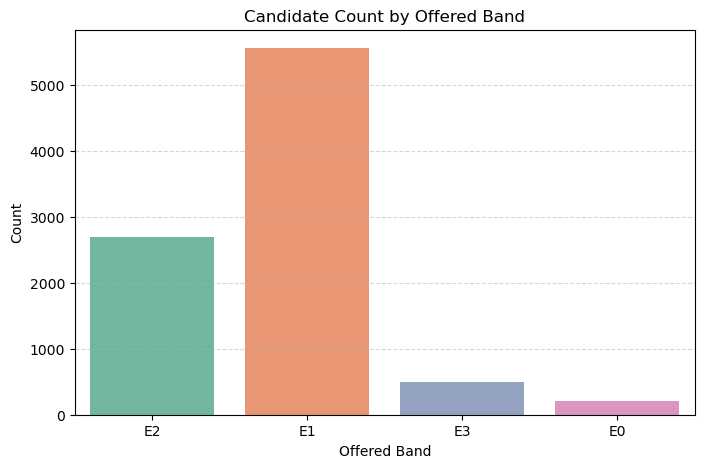

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Offered_Band",
    hue="Offered_Band",
    palette="Set2",
    legend=False
)

plt.xlabel("Offered Band")
plt.ylabel("Count")
plt.title("Candidate Count by Offered Band")
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.show()

In [56]:
data[data['Offered_Band'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
27,28,2207823,Yes,19,30,NaN,42.85,42.85,0.00,No,...,28.0,2,D13,Joined,2013-07-17,INFRA,Madhya Pradesh,Noida,R1,North
55,56,2286381,Yes,14,30,NaN,-12.50,-12.50,0.00,No,...,31.0,7,D4,Joined,2013-12-31,AXON,Chhattisgarh,Kolkata,R3,East
79,80,2365129,No,4,30,NaN,42.86,42.86,0.00,No,...,24.0,2,D12,Not Joined,2013-01-02,INFRA,Kerala,Cochin,R2,South
109,110,2452418,Yes,32,30,NaN,45.30,19.66,-25.64,No,...,30.0,6,D15,Joined,2013-02-20,ETS,Manipur,Bangalore,R2,South
138,139,2569520,No,5,30,NaN,-48.25,-48.25,0.00,No,...,31.0,2,D20,Joined,2013-03-30,INFRA,Telangana,Chennai,R2,South
167,168,2780669,Yes,29,60,NaN,33.33,266.67,233.34,No,...,32.0,1,D23,Not Joined,2013-05-11,ERS,Uttarkhand,Noida,R1,North
194,195,2845929,Yes,55,30,NaN,37.50,25.00,-12.50,No,...,25.0,2,D15,Joined,2013-06-15,INFRA,Manipur,Bangalore,R2,South
227,228,3211382,No,4,30,NaN,42.85,42.85,0.00,No,...,30.0,2,D22,Joined,2013-08-20,INFRA,Uttar Pradesh,Bangalore,R2,South
281,282,3300563,Yes,29,30,NaN,-30.00,-30.60,-0.60,No,...,33.0,5,D19,Joined,2013-11-05,CSMP,Tamil Nadu,Noida,R1,North
319,320,3379843,No,17,0,NaN,-12.04,-12.04,0.00,No,...,28.0,2,D3,Not Joined,2014-01-03,INFRA,Chandigarh,Chennai,R2,South


In [57]:
data[data['Offered_Band'] == 'E1'].head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
5,6,2117167,Yes,17,30,E1,42.83,42.83,0.00,No,...,34.0,2,D24,Joined,2013-02-03,INFRA,West Bengal,Noida,R1,North
7,8,2127572,Yes,16,0,E1,-20.00,-20.00,0.00,No,...,34.0,3,D6,Joined,2013-02-16,Healthcare,Goa,Noida,R1,North
8,9,2138169,No,1,30,E1,-22.22,-22.22,0.00,No,...,26.0,4,D5,Joined,2013-02-16,BFSI,Delhi,Gurgaon,R1,North
9,10,2143362,No,6,30,E1,240.00,220.00,-20.00,No,...,34.0,5,D23,Joined,2013-03-07,CSMP,Uttarkhand,Chennai,R2,South
18,19,2173730,No,1,30,E1,-13.42,42.86,56.28,No,...,34.0,2,D7,Joined,2013-05-14,INFRA,Gujarat,Gurgaon,R1,North


As there is only only 13 missing values in column `Offered_Band`, we can replace this with the `Mode` of the column i.e. E1

In [58]:
OB_mode = data['Offered_Band'].mode()[0]
OB_mode

'E1'

### Filling `Offered_Band` with `Mode` i.e. `E1`

In [59]:
data['Offered_Band'].fillna(OB_mode, inplace = True)

In [60]:
data['Offered_Band'].isna().sum()

np.int64(0)

In [61]:
data['Offered_Band'].value_counts()

Offered_Band
E1    5578
E2    2704
E3     502
E0     211
Name: count, dtype: int64

## Treatment of `Location_ID` column

In [62]:
data['Location_ID']

0       L001
1       L002
2       L001
3       L001
4       L001
        ... 
8990    L002
8991    L002
8992    L001
8993    L001
8994    L002
Name: Location_ID, Length: 8995, dtype: object

In [63]:
data['Location_ID'].isna().sum()
# This showing no NULL values.

np.int64(0)

In [64]:
data['Location_ID'].value_counts()

# But here we can see there are 13 NULL valued Rows as Null is in Object type

Location_ID
L002    3150
L001    2727
L004    2230
L005     341
L009     197
L003     146
L006     129
L008      48
Null      13
L007       8
L010       6
Name: count, dtype: int64

In [65]:
data[data['Location_ID'] == 'Null']

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
220,221,3110300,Yes,15,30,E1,42.83,42.83,0.00,No,...,26.0,2,D16,Joined,2013-08-06,INFRA,Odisha,NaN,NaN,NaN
289,290,3318393,Yes,0,30,E1,92.54,80.51,-12.03,No,...,23.0,2,D14,Joined,2013-11-16,INFRA,Maharashtra,NaN,NaN,NaN
449,450,2128714,Yes,41,45,E1,20.00,4.00,-16.00,No,...,33.0,7,D2,Joined,2014-05-24,AXON,Bihar,NaN,NaN,NaN
1157,1158,2222607,Yes,11,30,E1,42.86,42.86,0.00,No,...,28.0,2,D18,Joined,2013-05-14,INFRA,Rajasthan,NaN,NaN,NaN
2027,2028,2356982,Yes,1,90,E2,50.00,50.00,0.00,No,...,31.0,2,D24,Joined,2013-08-30,INFRA,West Bengal,NaN,NaN,NaN
2562,2563,2394715,Yes,9,30,E1,34.62,34.62,0.00,No,...,30.0,2,D10,Joined,2013-11-16,INFRA,Jharkhand,NaN,NaN,NaN
2774,2775,2419719,Yes,10,30,E1,86.89,86.89,0.00,No,...,35.0,2,D20,Joined,2013-10-18,INFRA,Telangana,NaN,NaN,NaN
2790,2791,2419919,Yes,20,30,E1,6.48,6.48,0.00,No,...,31.0,2,D8,Joined,2013-10-25,INFRA,Haryana,NaN,NaN,NaN
6941,6942,3304772,Yes,0,30,E1,48.15,57.41,9.26,No,...,27.0,2,D8,Joined,2013-12-22,INFRA,Haryana,NaN,NaN,NaN
7312,7313,3347807,No,4,30,E1,33.33,33.33,0.00,No,...,34.0,2,D18,Joined,2013-12-27,INFRA,Rajasthan,NaN,NaN,NaN


### Plot of `Location_ID`

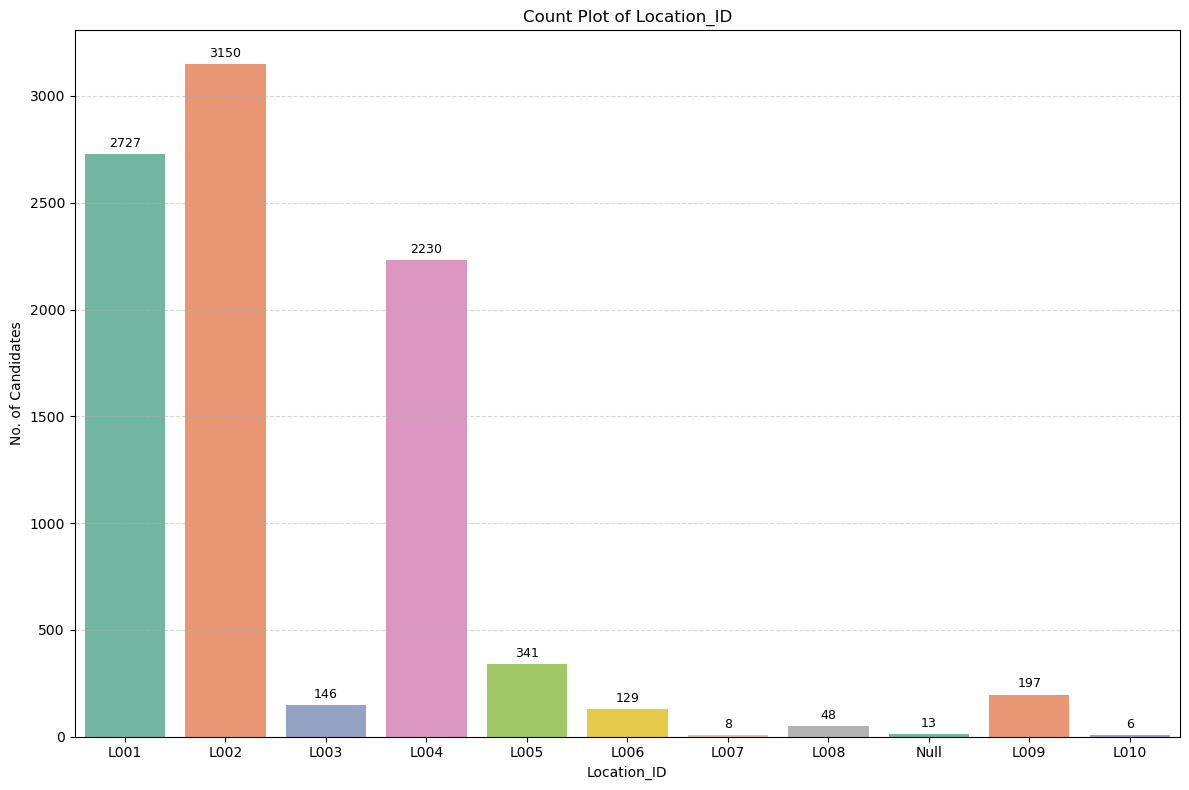

In [66]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_ID",
    hue="Location_ID",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As there is 13 NULL values and there are some Location_ID(s) which have value_counts less than the
NULL, so in this case `replcaing NULL with "Unknown"` will be a good choice.

In [67]:
data["Location_ID"] = data["Location_ID"].replace("Null", "Unknown")

In [68]:
data['Location_ID'].value_counts()

Location_ID
L002       3150
L001       2727
L004       2230
L005        341
L009        197
L003        146
L006        129
L008         48
Unknown      13
L007          8
L010          6
Name: count, dtype: int64

In [69]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

### Treatment of `Location_Name`

In [70]:
LN_NULL = data['Location_Name'].isna().sum()

print(f"No of Null values in Location_Name = {LN_NULL}")

No of Null values in Location_Name = 13


In [71]:
data['Location_Name'].value_counts()

Location_Name
Chennai      3150
Noida        2727
Bangalore    2230
Hyderabad     341
Mumbai        197
Gurgaon       146
Kolkata       129
Pune           48
Cochin          8
Ahmedabad       6
Name: count, dtype: int64

In [72]:
data['Location_Name'].unique()

array(['Noida', 'Chennai', 'Gurgaon', 'Bangalore', 'Hyderabad', 'Kolkata',
       'Cochin', 'Pune', nan, 'Mumbai', 'Ahmedabad'], dtype=object)

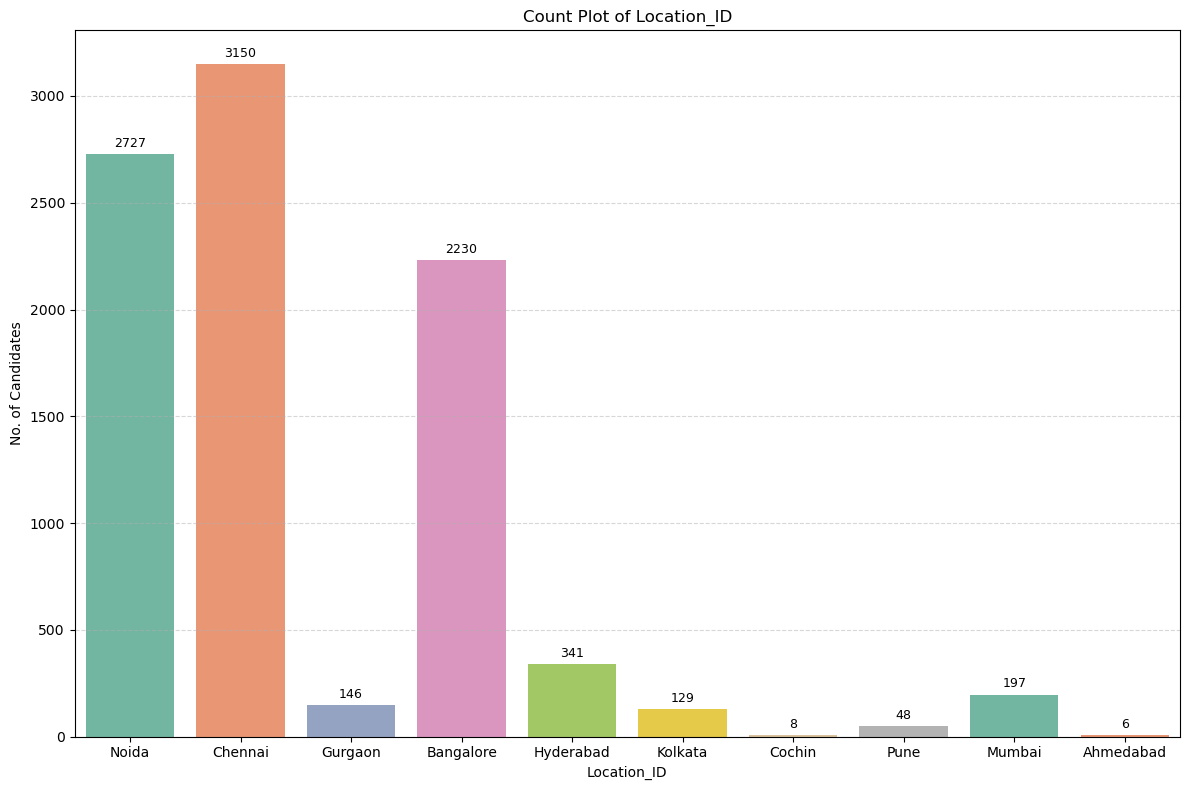

In [73]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_Name",
    hue="Location_Name",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As we have replced `NULL` with `Unknown` in Location_ID column.

In Location_Name going to do Same. 
Replacing `NULL` with `Unknown`

One thing to notice, in *Location_ID* column NULL values were as in Object dtype.

But in *Location_Name* column its in NULL format not in Object dtype.

So `.replace("Null" , "Unknown")` will not work, have to do `fillna()`

In [74]:
data['Location_Name'].fillna("Unknown", inplace = True)

In [75]:
data['Location_Name'].isna().sum()

np.int64(0)

#### Treatment of `Region_Id` column

In [76]:
data['Region_Id']

0       R1
1       R2
2       R1
3       R1
4       R1
        ..
8990    R2
8991    R2
8992    R1
8993    R1
8994    R2
Name: Region_Id, Length: 8995, dtype: object

In [77]:
data['Region_Id'].isna().sum()

np.int64(13)

In [78]:
data['Region_Id'].value_counts()

Region_Id
R2    5729
R1    2873
R4     251
R3     129
Name: count, dtype: int64

- Here we can see in `Region_Id` column the Null is in normal NULL format.

- But if we will do `.fillna("Unknown")` there will be only 13 values in `Unknown` bin.

- In this case as fillna("Unknown") can cause Data Imbalance that can directly affect the Model Performance.
So, Filling NULL with `Mode value(R2)` will be a safer option in this case.

In [79]:
RID_Mode = data['Region_Id'].mode()[0]

print(f"Mode of Region_Id column = {RID_Mode}")

Mode of Region_Id column = R2


In [80]:
data['Region_Id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Region_Id
Non-Null Count  Dtype 
--------------  ----- 
8982 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [81]:
# Filling NULL values in Region_Id with 'R2'
data['Region_Id'].fillna('R2', inplace = True)

In [82]:
data['Region_Id'].isna().sum()

np.int64(0)

## Treatment of `Region_Name` column

In [83]:
data['Region_Name']

0       North
1       South
2       North
3       North
4       North
        ...  
8990    South
8991    South
8992    North
8993    North
8994    South
Name: Region_Name, Length: 8995, dtype: object

In [84]:
RName_Null = data['Region_Name'].isna().sum()

print(f"Count of Null values in Region_Name column = {RName_Null}")

Count of Null values in Region_Name column = 13


In [85]:
data[['Region_Id','Region_Name']].value_counts()

Region_Id  Region_Name
R2         South          5729
R1         North          2873
R4         West            251
R3         East            129
Name: count, dtype: int64

- As we can see R2 is the South
- And in `Region_Id` column we have replaced NULL with `Mode("E2")`
- So here in `Region_Name` we have to fill NULL with `Mode("South")`

In [86]:
RN_Mode = data['Region_Name'].mode()[0]

print(f"Mode of Region_Name = {RN_Mode}")

Mode of Region_Name = South


In [87]:
# Replacing NULL with "South"

data['Region_Name'].fillna("South" , inplace = True)

In [88]:
data['Region_Name'].isna().sum()

np.int64(0)

In [89]:
data.isna().sum()

Sno                          0
Candidate_ID                 0
DOJ_Extended                 0
Acceptance_days              0
Notice_Period                0
Offered_Band                 0
Expected_CTC_hike_pct        0
Offered_CTC_hike_pct         0
CTC_diff_pct                 0
Joining_Bonus                0
Candidate_relocate_actual    0
Gender                       0
Candidate_Source             0
Experience_years             0
Location_ID                  0
Postal_Code                  0
Age                          0
LOB_Id                       0
Domicile_Id                  0
Status                       0
Date_of_Interview            0
LOB                          0
Domicile_Name                0
Location_Name                0
Region_Id                    0
Region_Name                  0
dtype: int64

### Null Value Treatment Done.

`There is no more NULL values in any column`

In [90]:
data.to_csv("(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv", index=False)

print("(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv - saved successfully!")

(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv - saved successfully!


 <a id="eda-eda"></a>

<h1 style="color: red; font-weight: 800;">EDA (Exploratory Data Analysis)</h1>

In [91]:
join = pd.read_csv("Joining_Status.csv")

join_df = pd.DataFrame(join)

join_df

,Candidate_Ref,Status
0,2110407,Joined
1,2112635,Joined
2,2112838,Joined
3,2115021,Joined
4,2115125,Joined
...,...,...
8990,3822427,Joined
8991,3828206,Joined
8992,3834159,Joined
8993,3835433,Joined


In [92]:
join_df['Status'].value_counts()

Status
Joined        7313
Not Joined    1682
Name: count, dtype: int64

In [93]:
join_df.isna().sum()

Candidate_Ref    0
Status           0
dtype: int64

In [94]:
list(data.columns)

['Sno',
 'Candidate_ID',
 'DOJ_Extended',
 'Acceptance_days',
 'Notice_Period',
 'Offered_Band',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Joining_Bonus',
 'Candidate_relocate_actual',
 'Gender',
 'Candidate_Source',
 'Experience_years',
 'Location_ID',
 'Postal_Code',
 'Age',
 'LOB_Id',
 'Domicile_Id',
 'Status',
 'Date_of_Interview',
 'LOB',
 'Domicile_Name',
 'Location_Name',
 'Region_Id',
 'Region_Name']

 <a id="moving-status-to-end"></a>

<h2 style="color: green; font-weight: 800;">Moving Status column to end of DataFrame</h2>

In [95]:
data1 = data.copy(deep=True)

# A copy (deep copy) of data DatFrame is made so that data DataFrame i.e. upto Data Pre-Processing can be safely preserved.
data1

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


In [96]:
status = data1['Status']
status

0       Joined
1       Joined
2       Joined
3       Joined
4       Joined
         ...  
8990    Joined
8991    Joined
8992    Joined
8993    Joined
8994    Joined
Name: Status, Length: 8995, dtype: object

In [97]:
data1.drop("Status", axis = 1 , inplace = True)


In [98]:
data1["Status"] = status

In [99]:
data1

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


# Reviewing Status column

In [100]:
total_candidate = data1.shape[0]

print(f"Total number of candidates = {total_candidate}")

Total number of candidates = 8995


In [101]:
joined = data1['Status'].value_counts().to_list()[0]
not_joined = data1['Status'].value_counts().to_list()[1]

print(f"Number of candidates joined = {joined}")
print(f"Number of candidated didn't join = {not_joined}")

Number of candidates joined = 7313
Number of candidated didn't join = 1682


In [102]:
joined + not_joined

8995

In [103]:
print(f"Percentage joined = {(joined / total_candidate) * 100 : .2f} %")
print(f"Percentage not joined = {(not_joined / total_candidate) * 100 : .2f} %")

Percentage joined =  81.30 %
Percentage not joined =  18.70 %


 <a id="outlier-treatment"></a>

<h2 style="color: green; font-weight: 800;">Outlier Treatment</h2>

In [104]:
numerical_columns = list(data1.select_dtypes(include = 'number'))

print(f"Numerical Columns = {numerical_columns}")

Numerical Columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


In [105]:
data1[numerical_columns].describe()

,Sno,Candidate_ID,Acceptance_days,Notice_Period,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Experience_years,Postal_Code,Age,LOB_Id
count,8995.000000,8.995000e+03,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,4498.000000,2.843647e+06,21.434464,39.291829,43.864804,40.657356,-3.207447,4.239022,453494.479266,29.910506,3.113063
std,2596.777169,4.863448e+05,25.811616,22.220239,29.788975,36.064060,27.412448,2.547571,180254.661181,4.092452,2.125902
min,1.000000,2.109586e+06,0.000000,0.000000,-68.830000,-60.530000,-200.000000,0.000000,122107.000000,20.000000,1.000000
25%,2249.500000,2.386476e+06,3.000000,30.000000,27.270000,22.090000,-12.755000,3.000000,201301.000000,27.000000,1.000000
50%,4498.000000,2.807482e+06,10.000000,30.000000,40.000000,36.000000,0.000000,4.000000,560034.000000,29.000000,2.000000
75%,6746.500000,3.300060e+06,33.000000,60.000000,53.850000,50.000000,0.000000,6.000000,600020.000000,34.000000,4.000000
max,8995.000000,3.836076e+06,224.000000,120.000000,359.770000,471.430000,385.720000,24.000000,700027.000000,60.000000,9.000000


In [106]:
# Number of outlier in every numerical column
for num_col in numerical_columns : 
    # Calculate IQR
    Q1 = data1[num_col].quantile(0.25)
    Q3 = data1[num_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = list(data1[num_col][(data1[num_col] < lower_bound) | (data[num_col] > upper_bound)])

    no_of_outliers = len(outliers)

    print(f"For column || {num_col} || number of outliers = {no_of_outliers}")

For column || Sno || number of outliers = 0
For column || Candidate_ID || number of outliers = 0
For column || Acceptance_days || number of outliers = 394
For column || Notice_Period || number of outliers = 42
For column || Expected_CTC_hike_pct || number of outliers = 522
For column || Offered_CTC_hike_pct || number of outliers = 663
For column || CTC_diff_pct || number of outliers = 1272
For column || Experience_years || number of outliers = 195
For column || Postal_Code || number of outliers = 0
For column || Age || number of outliers = 26
For column || LOB_Id || number of outliers = 15


In [107]:
data1[numerical_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sno                    8995 non-null   int64  
 1   Candidate_ID           8995 non-null   int64  
 2   Acceptance_days        8995 non-null   int64  
 3   Notice_Period          8995 non-null   int64  
 4   Expected_CTC_hike_pct  8995 non-null   float64
 5   Offered_CTC_hike_pct   8995 non-null   float64
 6   CTC_diff_pct           8995 non-null   float64
 7   Experience_years       8995 non-null   int64  
 8   Postal_Code            8995 non-null   int64  
 9   Age                    8995 non-null   float64
 10  LOB_Id                 8995 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 773.1 KB


### BoxPlot before the Outlier Treatment

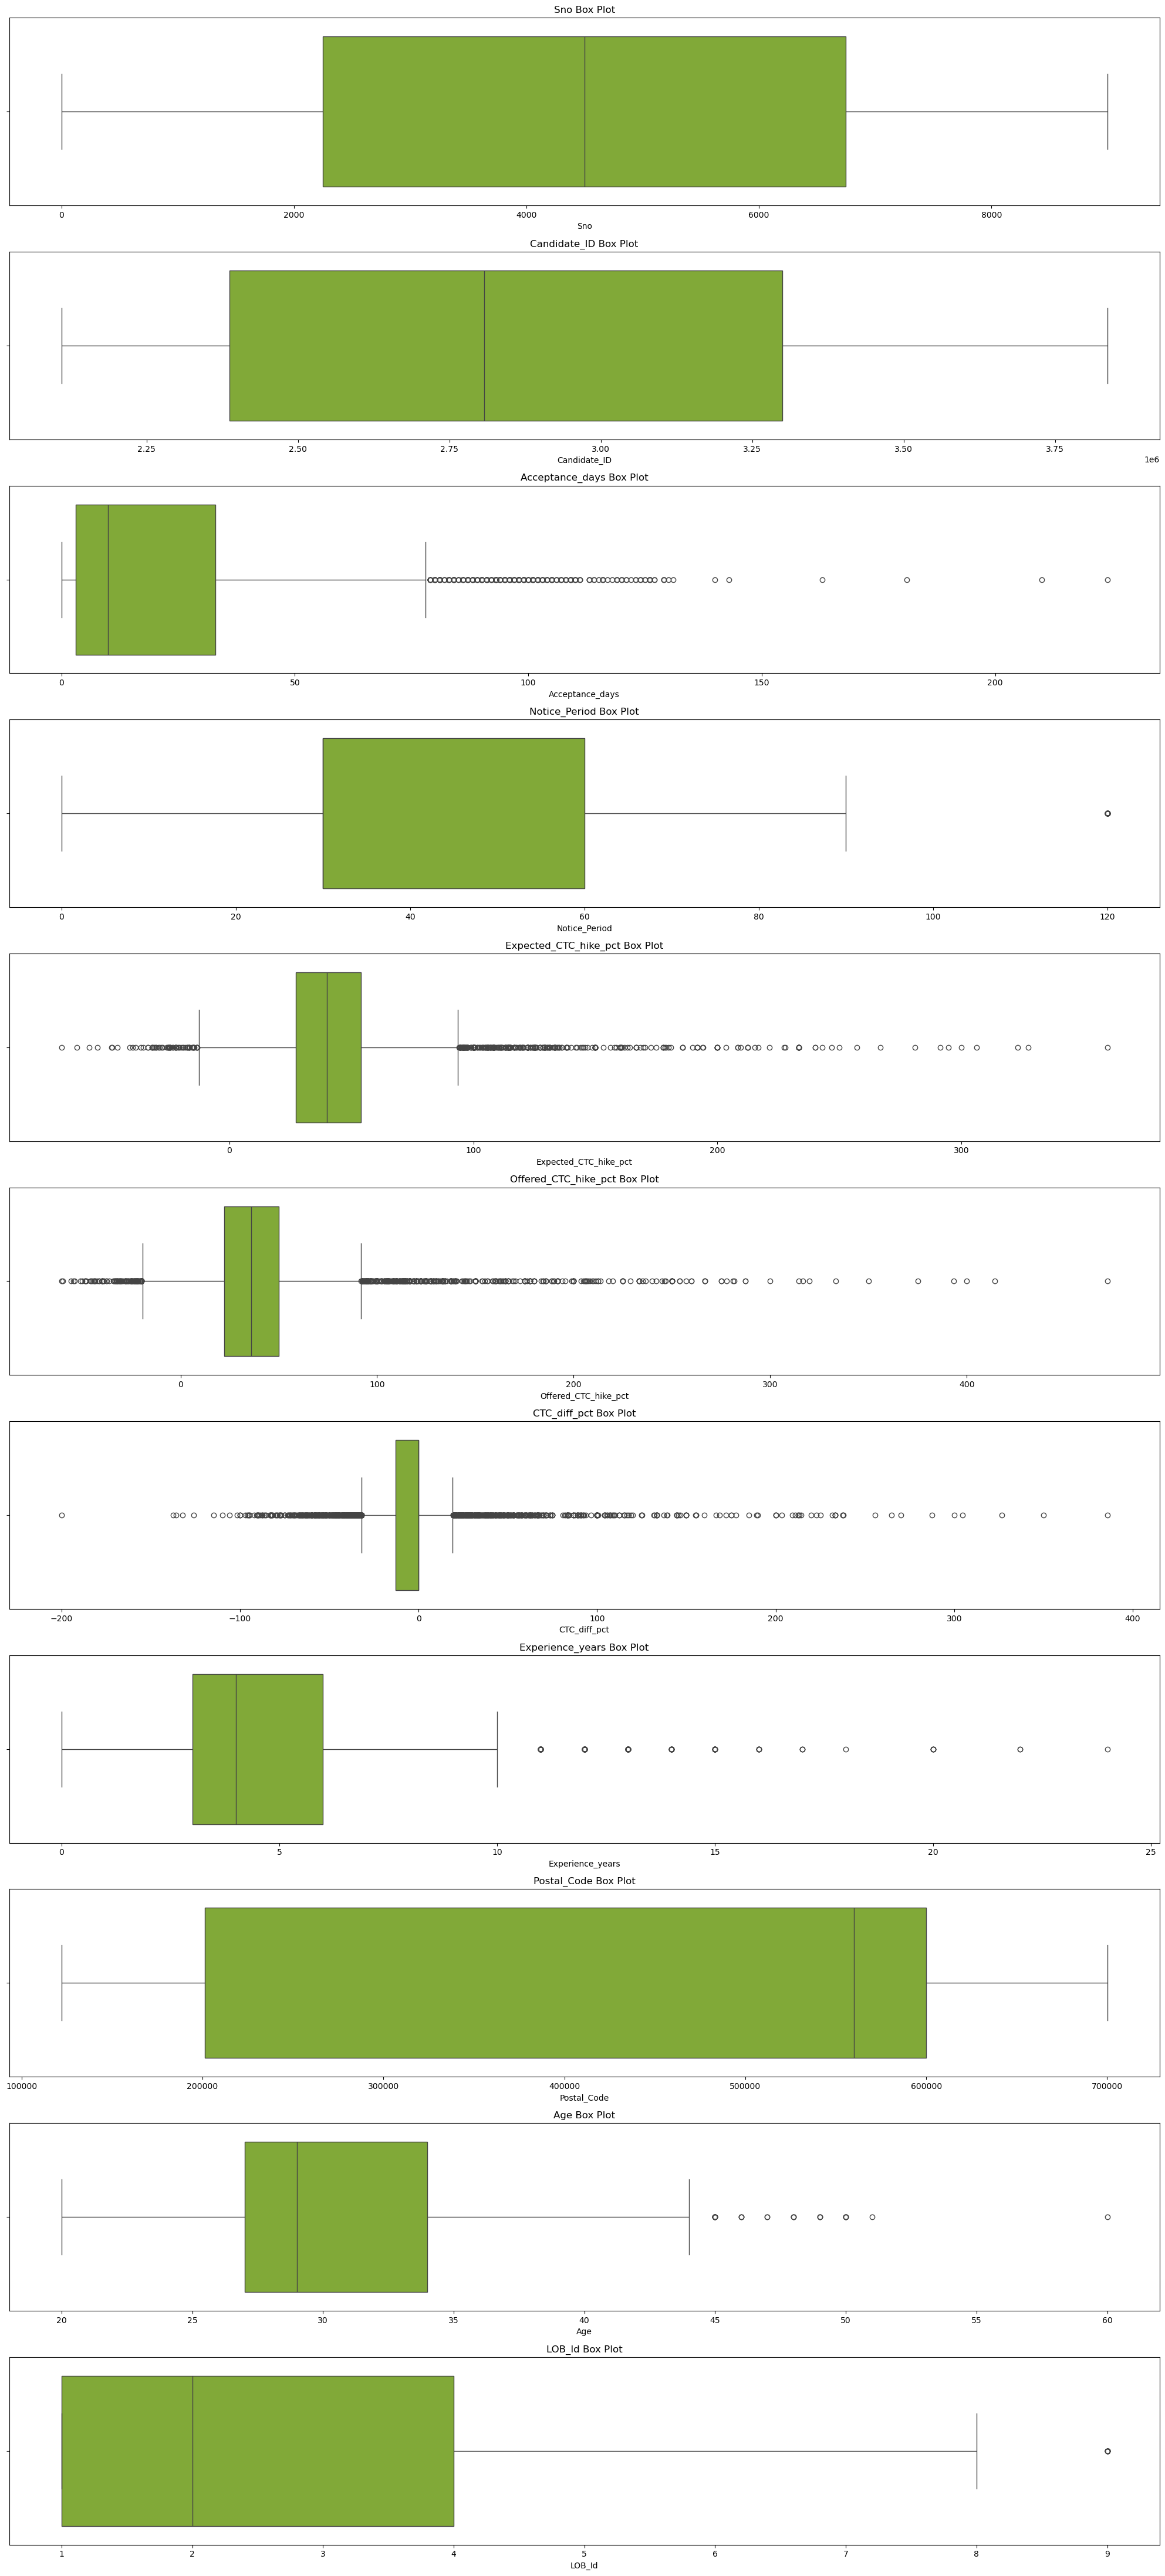

In [108]:
plt.figure(figsize=(20, 4 * len(numerical_columns)))

for count, num_col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, count)

    sns.boxplot(
        x=data1[num_col],
        color="#86BC25"
    )

    plt.title(f"{num_col} Box Plot")
    plt.xlabel(num_col)

plt.tight_layout()
plt.show()

In [109]:
# Outliers values for every numerical columns

for num_col in numerical_columns : 
    # Calculate IQR
    Q1 = data1[num_col].quantile(0.25)
    Q3 = data1[num_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = list(data1[num_col][(data1[num_col] < lower_bound) | (data[num_col] > upper_bound)])
    print(f"Column || {num_col} ||")
    print(f"Lower Bound = {lower_bound} & Upper Bound = {upper_bound}\n")
    print(f"For column || {num_col} || outliers = {outliers} \n")

Column || Sno ||
Lower Bound = -4496.0 & Upper Bound = 13492.0

For column || Sno || outliers = [] 

Column || Candidate_ID ||
Lower Bound = 1016100.75 & Upper Bound = 4670434.75

For column || Candidate_ID || outliers = [] 

Column || Acceptance_days ||
Lower Bound = -42.0 & Upper Bound = 78.0

For column || Acceptance_days || outliers = [120, 98, 83, 105, 84, 126, 106, 90, 103, 86, 93, 84, 107, 92, 79, 79, 108, 82, 210, 80, 97, 88, 90, 99, 86, 111, 87, 95, 98, 87, 96, 80, 91, 101, 98, 105, 79, 140, 93, 99, 86, 87, 93, 91, 123, 90, 88, 87, 104, 93, 98, 79, 126, 117, 87, 109, 96, 89, 88, 80, 98, 127, 81, 85, 86, 97, 81, 90, 81, 118, 101, 80, 114, 92, 81, 97, 105, 89, 88, 84, 95, 89, 84, 109, 97, 103, 92, 92, 110, 126, 129, 124, 96, 84, 85, 81, 86, 116, 103, 124, 84, 104, 92, 97, 181, 90, 123, 104, 129, 105, 86, 116, 91, 99, 94, 121, 121, 94, 93, 91, 119, 119, 102, 102, 96, 91, 113, 99, 88, 94, 109, 94, 95, 111, 107, 104, 109, 95, 97, 97, 115, 84, 110, 125, 114, 110, 81, 107, 96, 88, 10

In [110]:
# Checking min and max for numerical columns

for num_col in numerical_columns : 
    # Calculate IQR
    Q1 = data1[num_col].quantile(0.25)
    Q3 = data1[num_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_table = data1[num_col].min()
    max_table = data1[num_col].max()

    print(f"|| {num_col} ||")
    print(f"Max = {max_table} | Upper Bound = {upper_bound}")
    print(f"Min = {min_table} | Lower Bond = {lower_bound}\n")

|| Sno ||
Max = 8995 | Upper Bound = 13492.0
Min = 1 | Lower Bond = -4496.0

|| Candidate_ID ||
Max = 3836076 | Upper Bound = 4670434.75
Min = 2109586 | Lower Bond = 1016100.75

|| Acceptance_days ||
Max = 224 | Upper Bound = 78.0
Min = 0 | Lower Bond = -42.0

|| Notice_Period ||
Max = 120 | Upper Bound = 105.0
Min = 0 | Lower Bond = -15.0

|| Expected_CTC_hike_pct ||
Max = 359.77 | Upper Bound = 93.72
Min = -68.83 | Lower Bond = -12.600000000000005

|| Offered_CTC_hike_pct ||
Max = 471.43 | Upper Bound = 91.86500000000001
Min = -60.53 | Lower Bond = -19.775000000000002

|| CTC_diff_pct ||
Max = 385.72 | Upper Bound = 19.1325
Min = -200.0 | Lower Bond = -31.8875

|| Experience_years ||
Max = 24 | Upper Bound = 10.5
Min = 0 | Lower Bond = -1.5

|| Postal_Code ||
Max = 700027 | Upper Bound = 1198098.5
Min = 122107 | Lower Bond = -396777.5

|| Age ||
Max = 60.0 | Upper Bound = 44.5
Min = 20.0 | Lower Bond = 16.5

|| LOB_Id ||
Max = 9 | Upper Bound = 8.5
Min = 1 | Lower Bond = -3.5



In [111]:
numerical_columns

['Sno',
 'Candidate_ID',
 'Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Postal_Code',
 'Age',
 'LOB_Id']

### Columns to change the upper bound
1. Acceptance_days
2. Expected_CTC_hike_pct
3. Offered_CTC_hike_pct
4. CTC_diff_pct
5. Experience_years

### Changing Lower Bound and Upper Bound with quartiles +- 3 x (IQR)

In [112]:
# Excluded: IDs, postal codes, and category codes
columns_to_cap = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

for column in columns_to_cap:
    q1 = data1[column].quantile(0.25)
    q3 = data1[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (3 * iqr)
    upper_limit = q3 + (3 * iqr)

    min_table = data1[column].min()
    max_table = data1[column].max()
    
    outlier_count = (
        (data1[column] < lower_limit) |
        (data1[column] > upper_limit)
    ).sum()

    print(f"For column || {column} || number of outliers = {outlier_count}")
    print(f"|| {column} ||")
    print(f"Max = {max_table} | Upper Bound = {upper_limit}")
    print(f"Min = {min_table} | Lower Bond = {lower_limit}\n")

print("Outliers have been capped using 3 × IQR.")

For column || Acceptance_days || number of outliers = 23
|| Acceptance_days ||
Max = 224 | Upper Bound = 123.0
Min = 0 | Lower Bond = -87.0

For column || Notice_Period || number of outliers = 0
|| Notice_Period ||
Max = 120 | Upper Bound = 150.0
Min = 0 | Lower Bond = -60.0

For column || Expected_CTC_hike_pct || number of outliers = 135
|| Expected_CTC_hike_pct ||
Max = 359.77 | Upper Bound = 133.59
Min = -68.83 | Lower Bond = -52.47000000000001

For column || Offered_CTC_hike_pct || number of outliers = 206
|| Offered_CTC_hike_pct ||
Max = 471.43 | Upper Bound = 133.73000000000002
Min = -60.53 | Lower Bond = -61.64

For column || CTC_diff_pct || number of outliers = 541
|| CTC_diff_pct ||
Max = 385.72 | Upper Bound = 38.265
Min = -200.0 | Lower Bond = -51.019999999999996

For column || Experience_years || number of outliers = 17
|| Experience_years ||
Max = 24 | Upper Bound = 15.0
Min = 0 | Lower Bond = -6.0

For column || Age || number of outliers = 1
|| Age ||
Max = 60.0 | Upper B

### Changing Q1 and Q3 as 5 and 95 percentile

In [113]:
columns_to_cap = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

for column in columns_to_cap:
    lower_limit = data1[column].quantile(0.05)
    upper_limit = data1[column].quantile(0.99)

    # data1[column] = data1[column].clip(
    #     lower=lower_limit,
    #     upper=upper_limit
    # )

    min_table = data1[column].min()
    max_table = data1[column].max()

    print(f"|| {column} ||")
    print(f"Max = {max_table} | Upper Bound = {upper_limit}")
    print(f"Min = {min_table} | Lower Bond = {lower_limit}\n")

print("Outliers capped using the 5th and 95th percentiles.")

|| Acceptance_days ||
Max = 224 | Upper Bound = 103.05999999999949
Min = 0 | Lower Bond = 0.0

|| Notice_Period ||
Max = 120 | Upper Bound = 90.0
Min = 0 | Lower Bond = 0.0

|| Expected_CTC_hike_pct ||
Max = 359.77 | Upper Bound = 150.0
Min = -68.83 | Lower Bond = 7.69

|| Offered_CTC_hike_pct ||
Max = 471.43 | Upper Bound = 185.71
Min = -60.53 | Lower Bond = 0.0

|| CTC_diff_pct ||
Max = 385.72 | Upper Bound = 100.6731999999981
Min = -200.0 | Lower Bond = -37.373999999999995

|| Experience_years ||
Max = 24 | Upper Bound = 13.0
Min = 0 | Lower Bond = 1.0

|| Age ||
Max = 60.0 | Upper Bound = 40.0
Min = 20.0 | Lower Bond = 24.0

Outliers capped using the 5th and 95th percentiles.


### Changing Q1 and Q3 as 3 and 99 percentile

In [114]:
columns_to_check = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

for column in columns_to_check:
    lower_limit = data1[column].quantile(0.03)
    upper_limit = data1[column].quantile(0.99)

    outlier_count = (
        (data1[column] < lower_limit) |
        (data1[column] > upper_limit)
    ).sum()

    print(f"For column || {column} || number of outliers = {outlier_count}")
    print(f"Max = {data1[column].max()} | Upper Bound = {upper_limit}")
    print(f"Min = {data1[column].min()} | Lower Bound = {lower_limit}\n")

print("Outliers counted using the 5th and 99th percentile limits.")

For column || Acceptance_days || number of outliers = 90
Max = 224 | Upper Bound = 103.05999999999949
Min = 0 | Lower Bound = 0.0

For column || Notice_Period || number of outliers = 42
Max = 120 | Upper Bound = 90.0
Min = 0 | Lower Bound = 0.0

For column || Expected_CTC_hike_pct || number of outliers = 351
Max = 359.77 | Upper Bound = 150.0
Min = -68.83 | Lower Bound = 1.7355999999999994

For column || Offered_CTC_hike_pct || number of outliers = 358
Max = 471.43 | Upper Bound = 185.71
Min = -60.53 | Lower Bound = -9.689

For column || CTC_diff_pct || number of outliers = 360
Max = 385.72 | Upper Bound = 100.6731999999981
Min = -200.0 | Lower Bound = -45.934400000000004

For column || Experience_years || number of outliers = 300
Max = 24 | Upper Bound = 13.0
Min = 0 | Lower Bound = 1.0

For column || Age || number of outliers = 140
Max = 60.0 | Upper Bound = 40.0
Min = 20.0 | Lower Bound = 23.0

Outliers counted using the 5th and 99th percentile limits.


In [115]:
data1.shape

(8995, 26)

### After observing all 3 different methods for Outlier Treatment, we can conlcude that - 
- `Forwarding ahead with 3 x of IQR as Outlier Treatment`
- `Clip the outlier cap with Upper limit and Lower limit`


### Capping outliers with Lower and Upper bounds determined as Q1 | Q3 += 3 x (IQR)

In [116]:
columns_to_cap = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

iqr_limits = {}

for column in columns_to_cap:
    q1 = data1[column].quantile(0.25)
    q3 = data1[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (3 * iqr)
    upper_limit = q3 + (3 * iqr)

    iqr_limits[column] = (lower_limit, upper_limit)

    data1[column] = data1[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outliers capped using 3 × IQR limits.")

Outliers capped using 3 × IQR limits.


### Checking for outliers if remained in case.

In [117]:
outlier_check = []

for column in columns_to_cap:
    lower_limit, upper_limit = iqr_limits[column]

    outlier_count = (
        (data1[column] < lower_limit) |
        (data1[column] > upper_limit)
    ).sum()

    outlier_check.append({
        "Column": column,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outliers After Treatment": outlier_count
    })

outlier_check = pd.DataFrame(outlier_check)

outlier_check

,Column,Lower Limit,Upper Limit,Outliers After Treatment
0,Acceptance_days,-87.00,123.000,0
1,Notice_Period,-60.00,150.000,0
2,Expected_CTC_hike_pct,-52.47,133.590,0
3,Offered_CTC_hike_pct,-61.64,133.730,0
4,CTC_diff_pct,-51.02,38.265,0
5,Experience_years,-6.00,15.000,0
6,Age,6.00,55.000,0


### BoxPlots after the Outlier Treatment


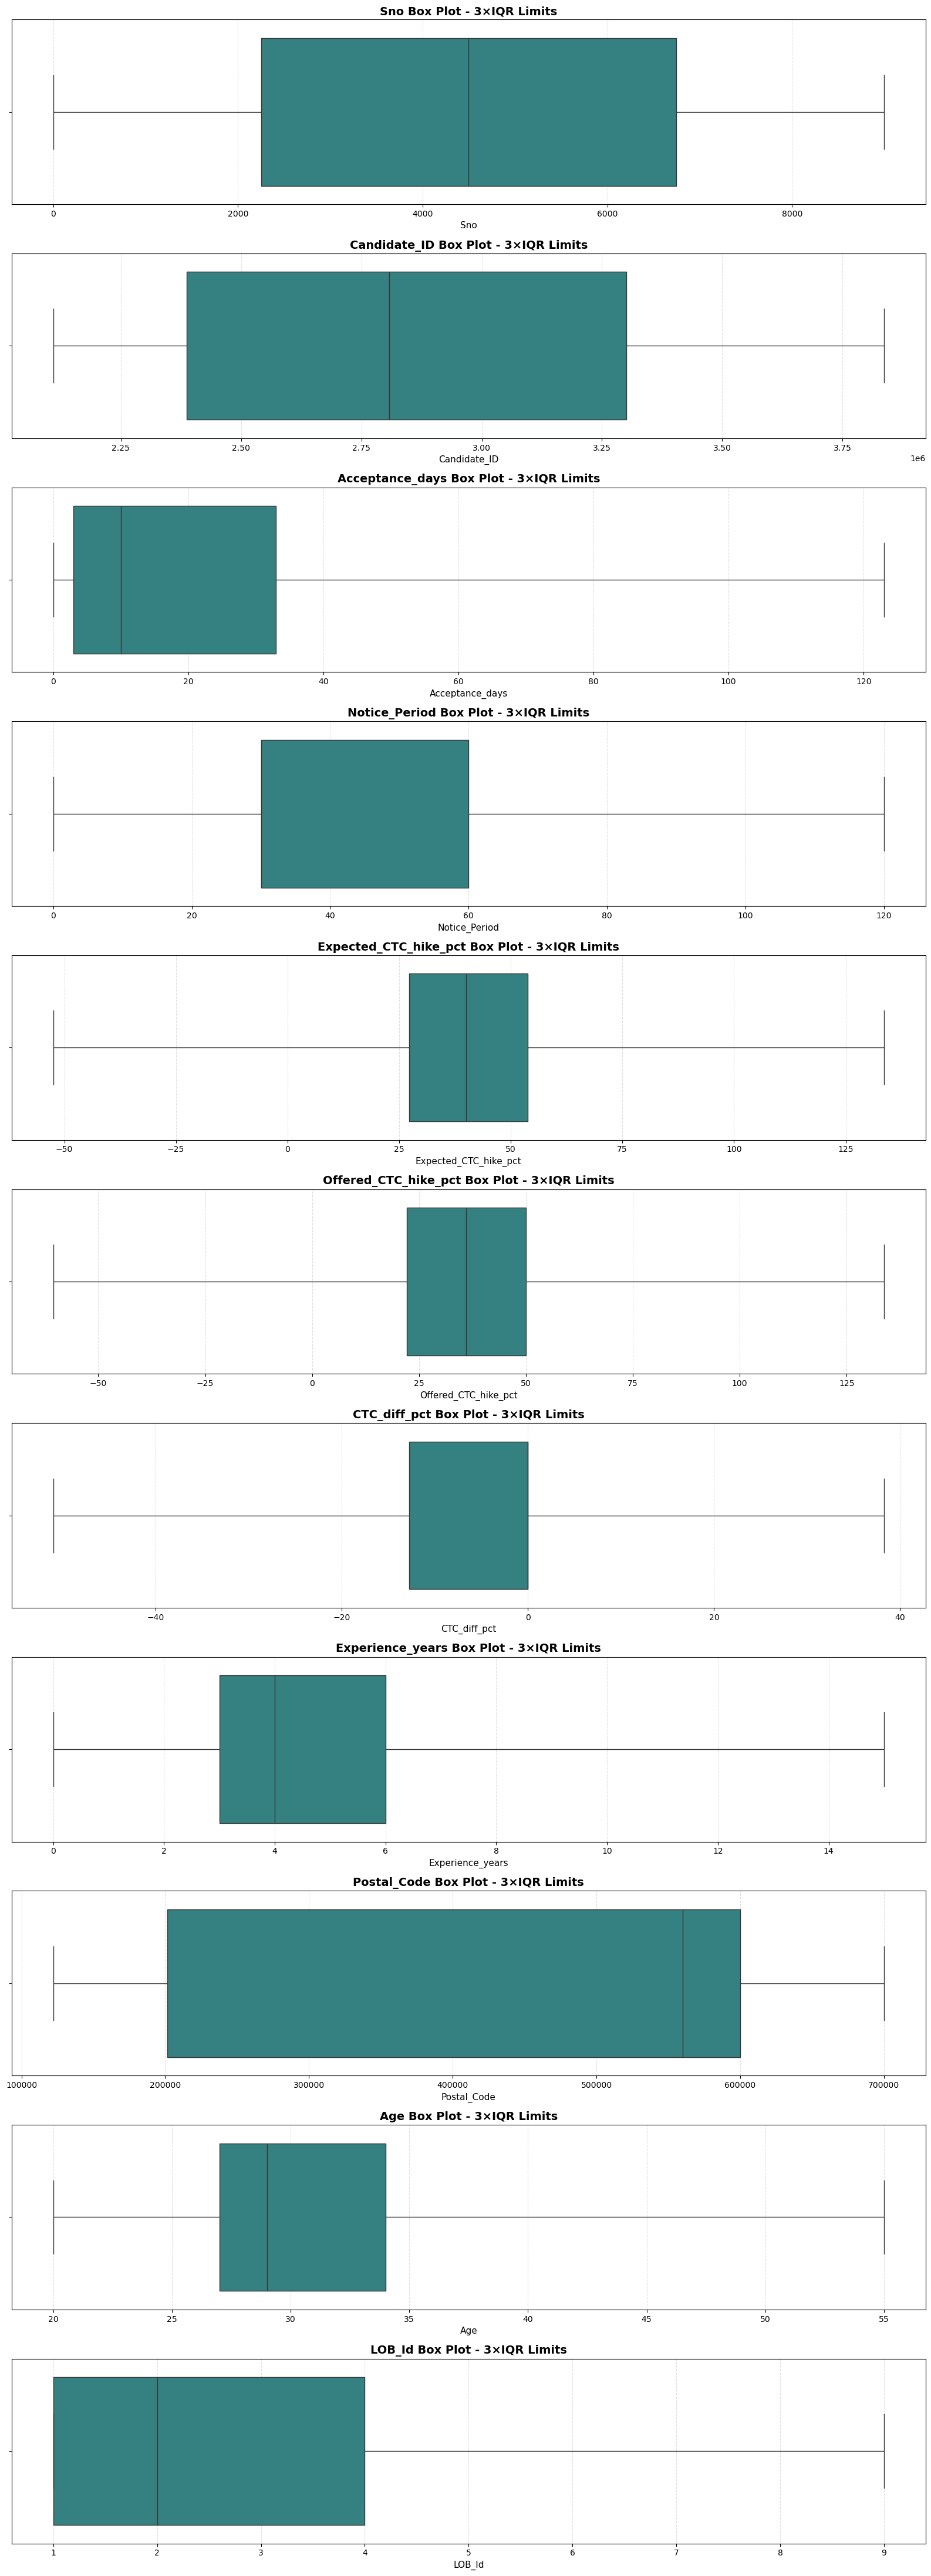

In [118]:
fig, axes = plt.subplots(
    nrows=len(numerical_columns),
    ncols=1,
    figsize=(16, 4 * len(numerical_columns))
)

axes = axes.flatten()

for ax, column in zip(axes, numerical_columns):
    sns.boxplot(
        x=data1[column].dropna(),
        color="#298C8C",
        whis=3,
        ax=ax
    )

    ax.set_title(
        f"{column} Box Plot - 3×IQR Limits",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel(column, fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Outliers Treatment Done!

 <a id="date-time"></a>

<h2 style="color: green; font-weight: 800;">Treatment of Date_of_Interview Column</h2>

- Its data type is `Object`
- So have to handle it, either have to change its Data Type or separating Date, Month, Year in different columns.

In [119]:
print(f"Data Type of Date_of_Interview Column = {data1['Date_of_Interview'].dtype}")
print(data1['Date_of_Interview'].head(10))
print(data1['Date_of_Interview'].unique()[:10]) 

Data Type of Date_of_Interview Column = object
0    2013-01-08
1    2013-01-12
2    2013-01-25
3    2013-01-27
4    2013-01-28
5    2013-02-03
6    2013-02-11
7    2013-02-16
8    2013-02-16
9    2013-03-07
Name: Date_of_Interview, dtype: object
['2013-01-08' '2013-01-12' '2013-01-25' '2013-01-27' '2013-01-28'
 '2013-02-03' '2013-02-11' '2013-02-16' '2013-03-07' '2013-04-03']


### Changing the data type of Date_of_Interview column from `Object` to `Date_Time`

In [120]:
data1['Date_of_Interview'] = pd.to_datetime(data1['Date_of_Interview'], errors='coerce')

In [121]:
print(f"Data Type of Date_of_Interview Column = {data1['Date_of_Interview'].dtype}")


Data Type of Date_of_Interview Column = datetime64[ns]


 <a id="numerical-plots"></a>

<h2 style="color: green; font-weight: 800;">Distribution Plots of Numerical Columns</h2>

In [122]:
numerical_columns

['Sno',
 'Candidate_ID',
 'Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Postal_Code',
 'Age',
 'LOB_Id']

Columns removed from Visualization = 
1. Sno
2. Candiadte_ID
3. Postal_Code
4. LOB_Id


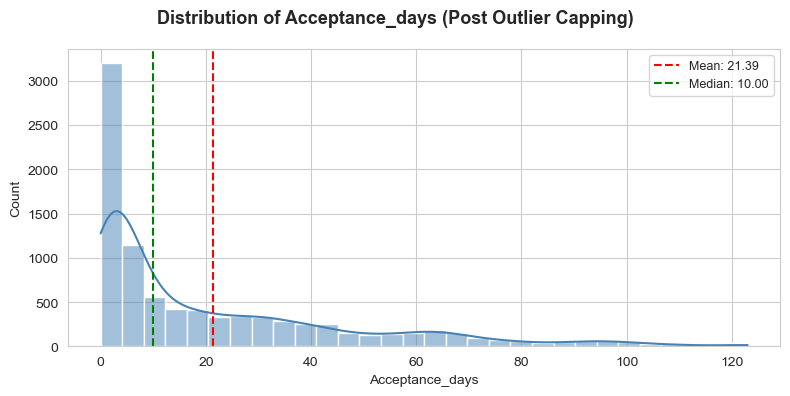

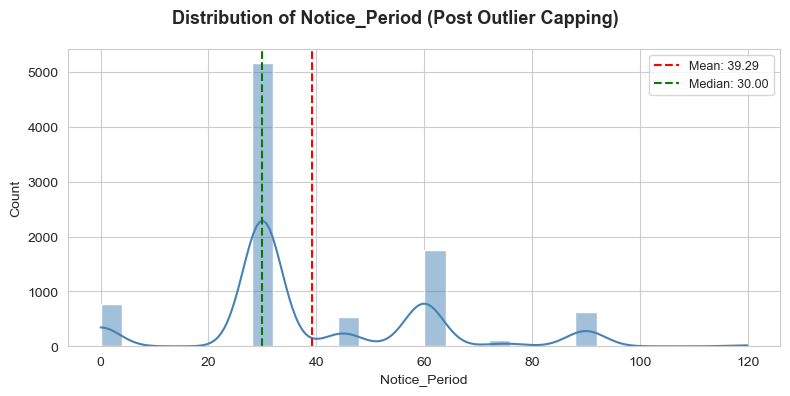

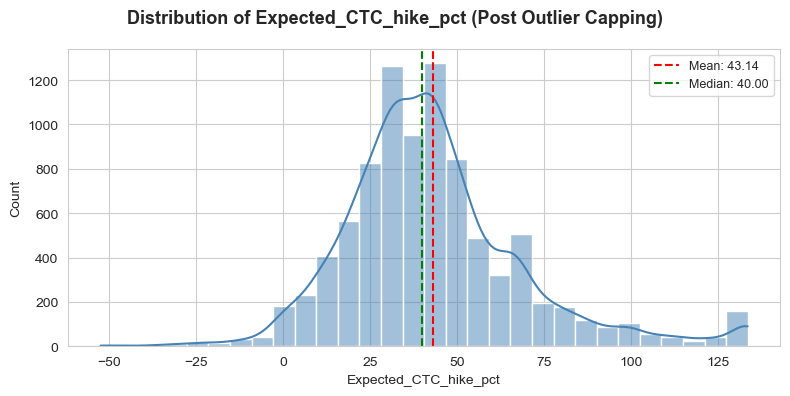

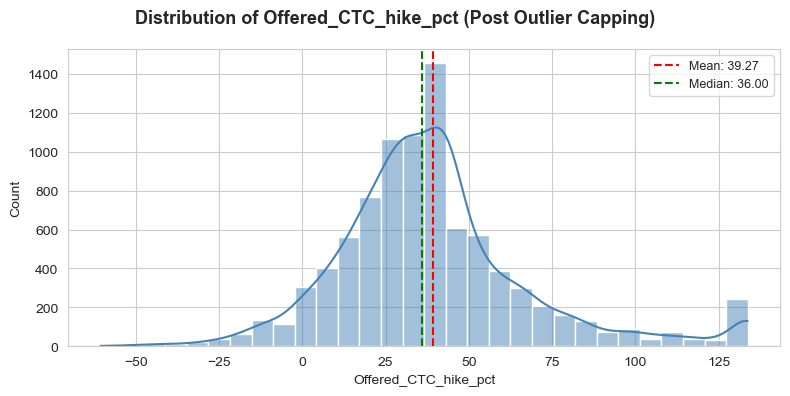

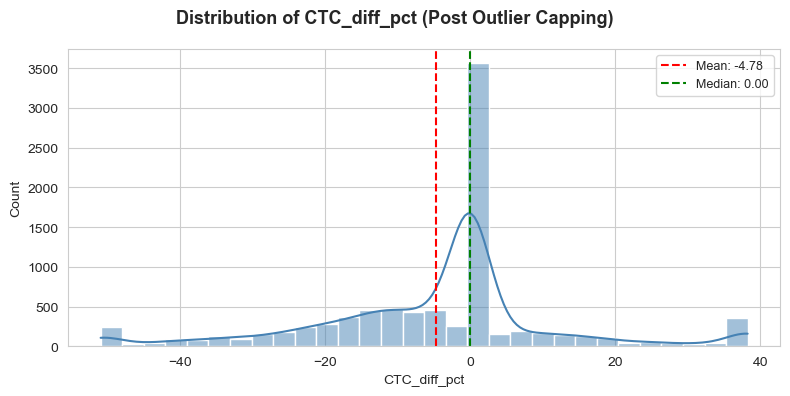

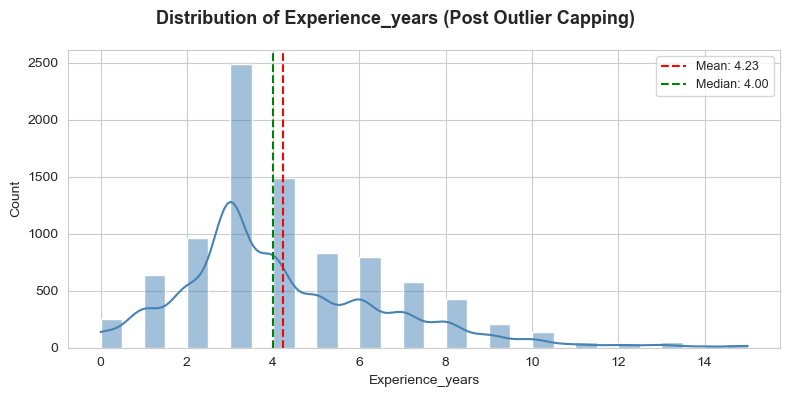

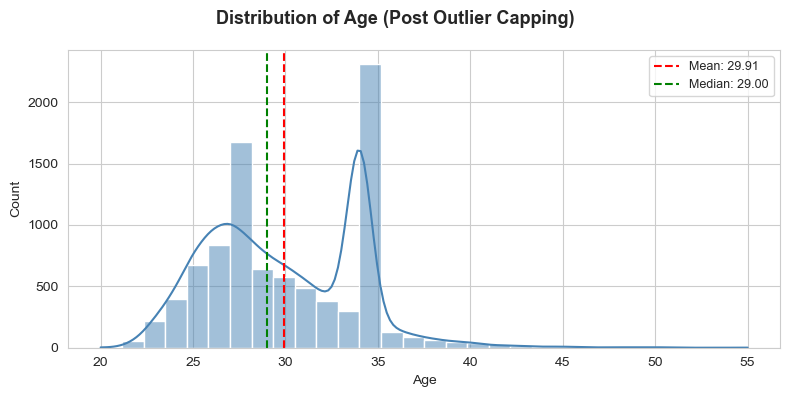

In [126]:
sns.set_style("whitegrid")

numerical_columns2 = [
 'Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Age']

for col in numerical_columns2:
    lower_limit, upper_limit = iqr_limits[col]

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f'Distribution of {col} (Post Outlier Capping)', 
                 fontsize=13, fontweight='bold')

    sns.histplot(data1[col].dropna(), kde=True, ax=ax,
                 color='steelblue', edgecolor='white', bins=30)

    ax.axvline(data1[col].mean(),   color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean: {data1[col].mean():.2f}')
    ax.axvline(data1[col].median(), color='green',  linestyle='--',
               linewidth=1.5, label=f'Median: {data1[col].median():.2f}')
    # ax.axvline(lower_limit, color='orange', linestyle=':',
    #            linewidth=1.5, label=f'Lower Cap: {lower_limit:.2f}')
    # ax.axvline(upper_limit, color='purple', linestyle=':',
    #            linewidth=1.5, label=f'Upper Cap: {upper_limit:.2f}')

    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# Insights from the Distribution Diagrams of Numerical Columns

1. ### **`Acceptance_days`**

- *Heavy right skewed* — majority of candidates accepted within 0–10 days (median: 10), but a long tail stretches to 120+ days
- *Mean (21.39) is pulled far right of median* — classic skew signal

2. ### **`Notice_Period`**

- *Multi-modal distribution* — clear spikes at 0, 30, 60, and 90 days — this makes perfect sense as notice periods are typically fixed contractual values
- Median of 30 days is the dominant notice period
- Mean (39.29) is dragged up by the 60/90-day clusters


3. ### **`Expected_CTC_hike_pct`**

- *Fairly normal with a slight right skew* — centered around 40% (median)
- *Mean and median are very close (43.14 vs 40)* — relatively balanced distribution
- *Spike near the upper cap (~130%) worth noting* — some candidates had very high expectations


4. ### **`Offered_CTC_hike_pct`**

- *Very similar shape to Expected_CTC_hike_pct* — near-normal, centered around 36–39%
- *Slightly lower median (36) vs expected (40)* — suggests offers came in below candidate expectations on average
- *Same upper cap spike visible* — mirrors the expected hike pattern

5. ### **`CTC_diff_pct`**

- *Most candidates were offered less than expected* — left skew with mean at -4.78 while median sits at 0
- Large spread from -50 to 0 suggests many candidates were significantly under-offered
- *Small spike near upper cap (38.27)* — a niche group received well above expectations


6. ### **`Experience_years`**

- *Sharp dominant peak at 3–4 years* — predominantly an early-career hiring pool (mean: 4.23, median: 4.00)
- A gradual right tail up to 15 years indicates a smaller but present mid-to-senior segment
- Secondary clusters around 6–10 years suggest two distinct hiring tracks


7. ### **`Age`**

- *Bimodal distribution with clear peaks at ~28 and ~34 years*, aligning with the two experience clusters
- *Mean (29.91) and median (29.00) are very close* — distribution is balanced around late 20s
- Workforce skews young, concentrated in the late 20s to early 30s

# Plots for Individual Categorical Columns

In [127]:
categorical_columns = list(data1.select_dtypes(include = 'object'))

print(f"Categorical Columns = {categorical_columns}")

Categorical Columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name', 'Status']


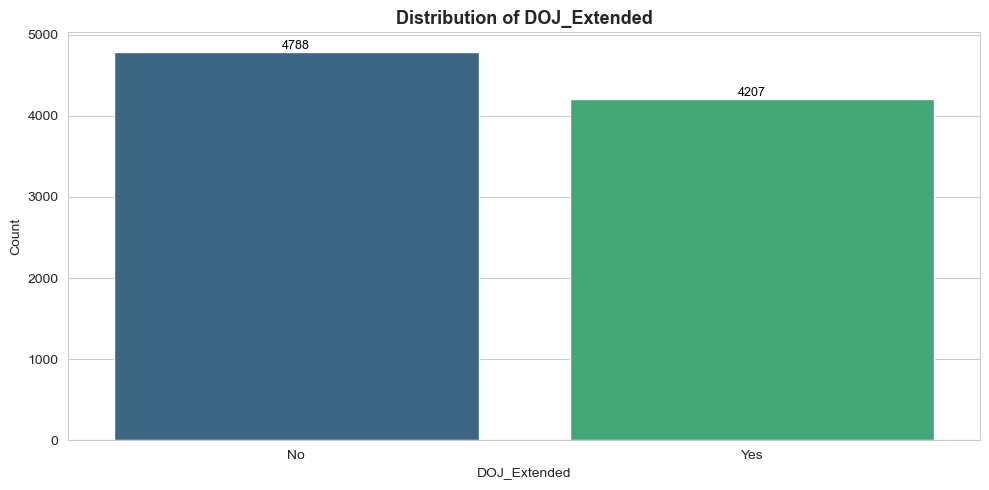

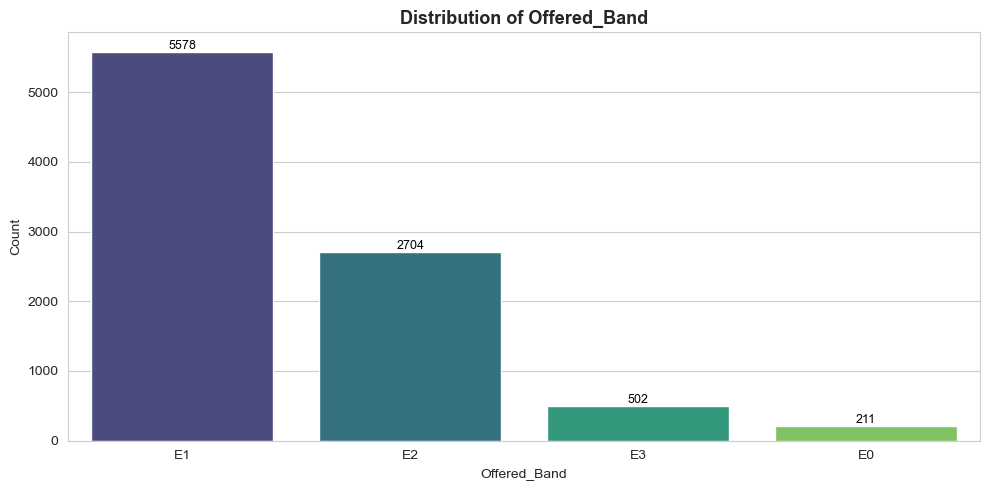

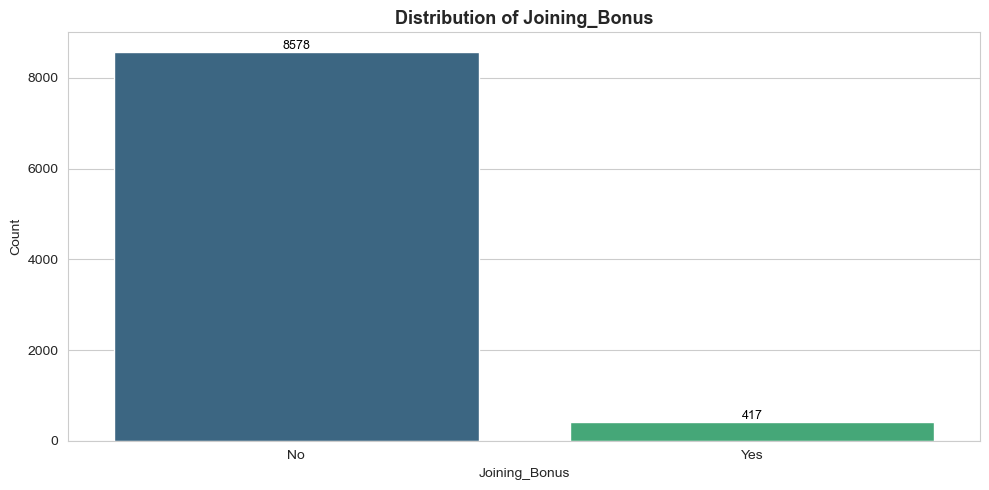

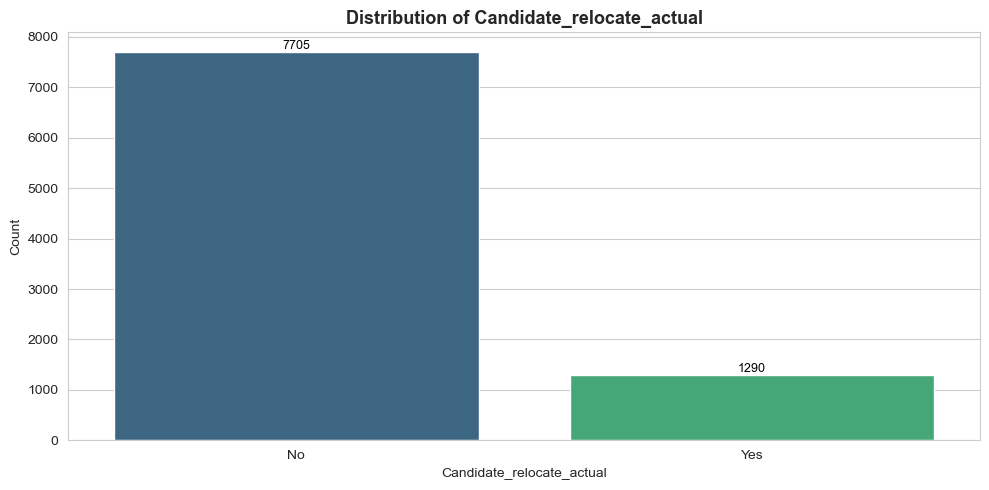

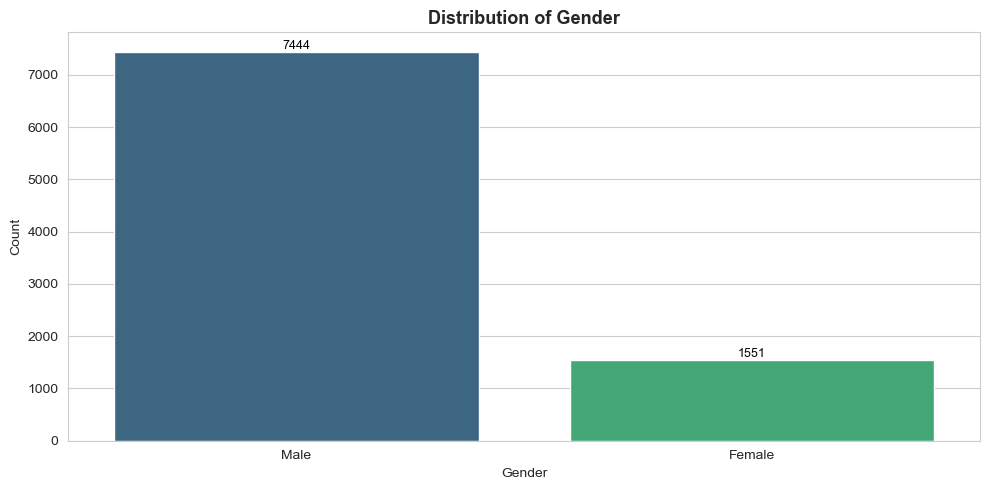

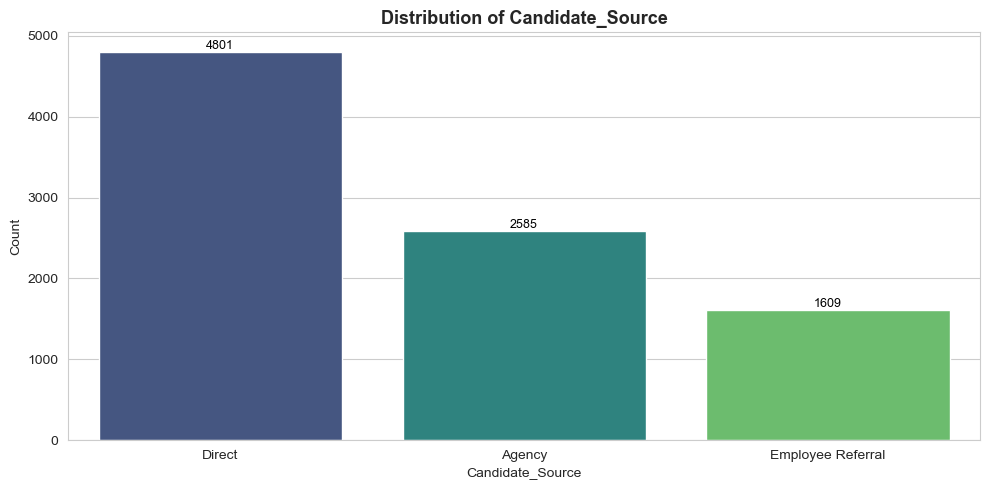

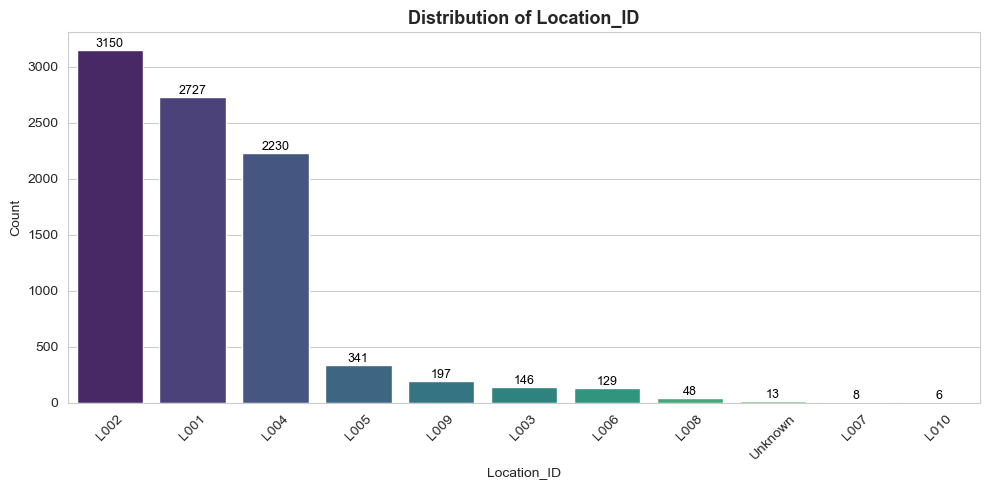

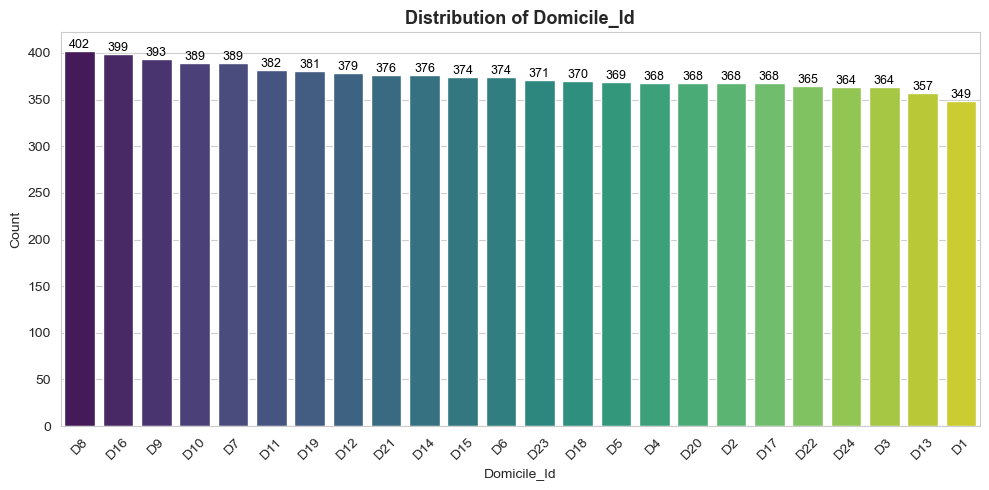

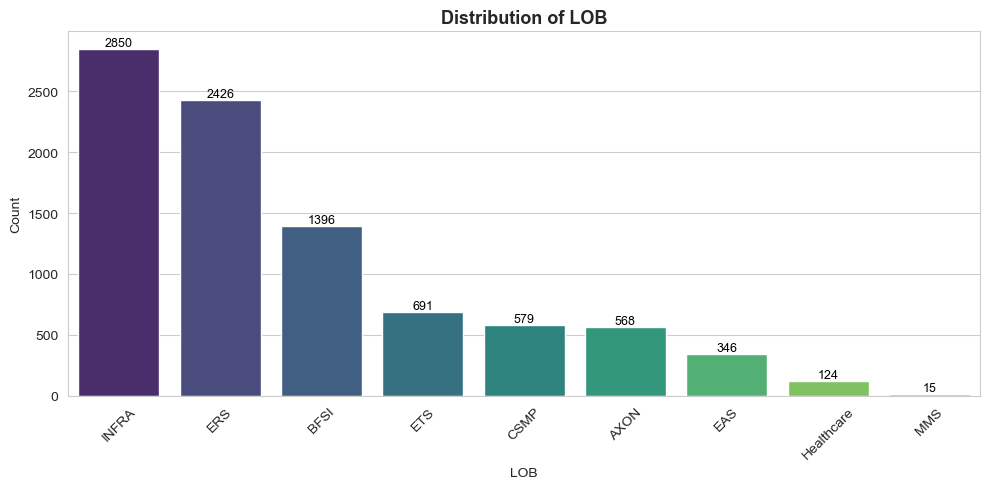

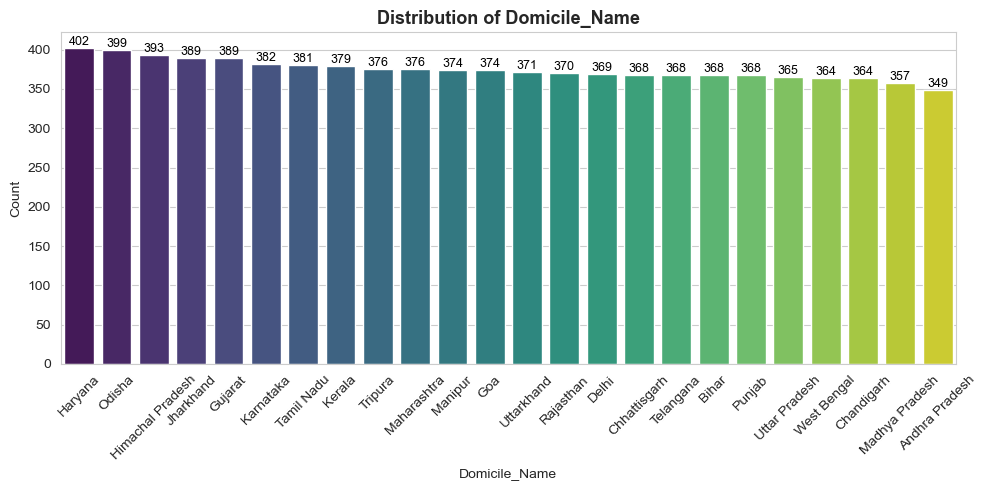

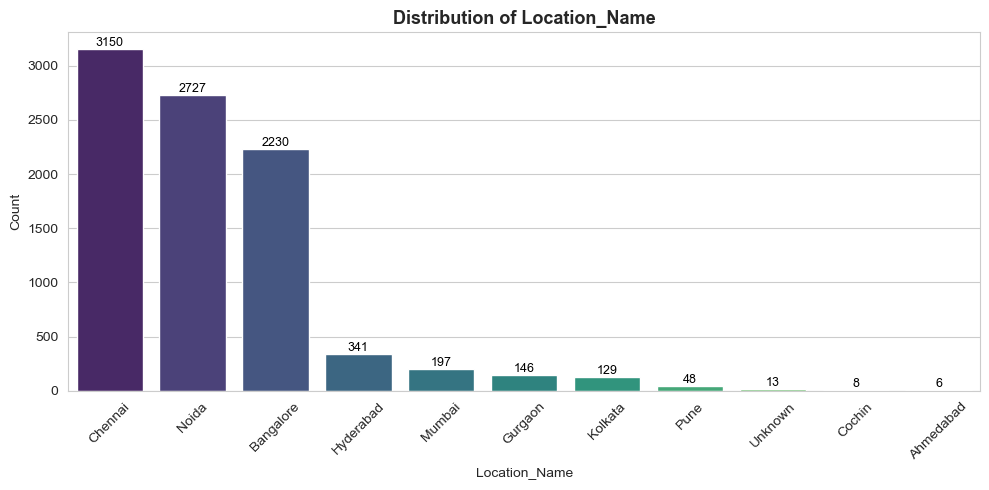

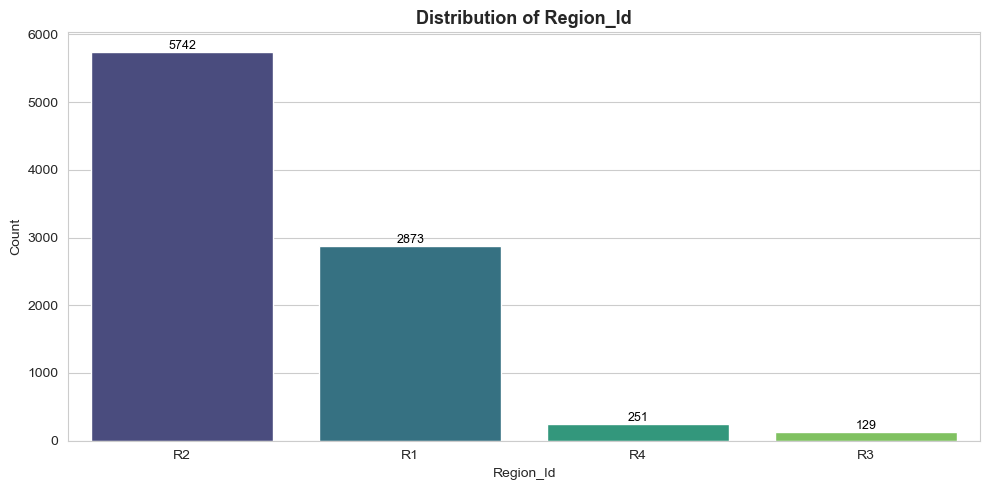

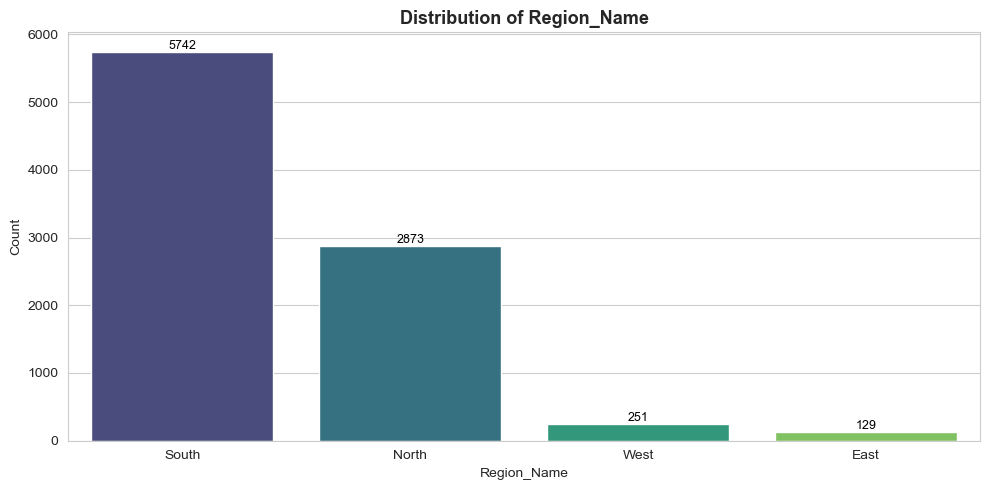

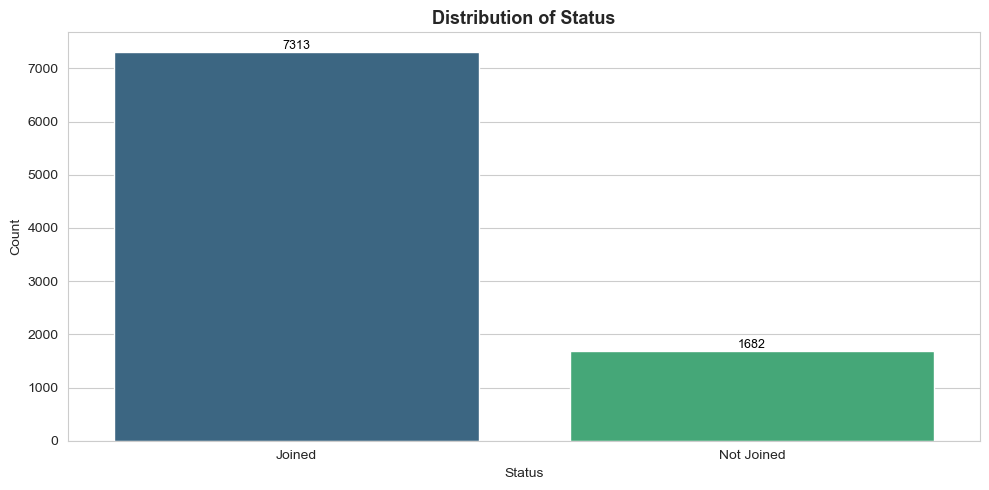

In [144]:
sns.set_style("whitegrid")

for col in categorical_columns:
    value_counts = data1[col].value_counts()

    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax,
                palette='viridis', edgecolor='white')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black')

    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x')

    if len(value_counts.index) > 5:
       plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Insights from the Distribution Diagrams of Categorical Columns


1. *`DOJ_Extended`*

- Nearly balanced split — 53% candidates did not extend DOJ vs 47% who did, suggesting DOJ extension is a common occurrence worth investigating for its impact on joining
- High "Yes" volume (4207) signals a systemic delay pattern, not an exception



2. *`Offered_Band`*

- Heavily skewed toward E1 — E1 alone accounts for ~62% of all offers, with E2 at 30%; E0 and E3 are negligible minorities
- Band distribution is entry-level dominated, which may explain higher dropout rates if compensation expectations don't match



3. *`Joining_Bonus`*

- Extremely imbalanced — 95.4% candidates received no joining bonus, making this feature nearly a constant with very low predictive signal
- The 417 who received a bonus form too small a group to draw strong conclusions without targeted analysis



4. *`Candidate_relocate_actual`*

- Majority didn't relocate (85.7%) — relocation is an exception, not the norm in this dataset
- The 1290 who relocated represent a key subgroup to watch for dropout risk given the added friction of moving



5. *`Gender`*

- Heavily male-dominated — Males make up ~83% (7444) of candidates vs 17% Female (1551), indicating a strong gender skew in the hiring process



6. *`Candidate_Source`*

- Direct hiring leads at 53%, followed by Agency (28%) and Employee Referral (18%) — referral channel is notably smaller
- Agency sourcing, being the costliest channel, warrants a dropout rate check to validate ROI



7. *`Location_ID`*

- Top 3 locations (L002, L001, L004) account for ~90% of all candidates — remaining 7 locations are negligible in volume
- Heavy concentration means location-level insights are effectively driven by just Chennai, Noida, and Bangalore



8. *`Domicile_Id`*

- Remarkably uniform distribution — all 24 domicile IDs hover between 349–402 candidates, suggesting deliberate geographic spread in sourcing
- No single domicile dominates, making this a well-balanced feature across states



9. *`LOB`*

- INFRA and ERS together account for ~58% of candidates — bottom 3 (Healthcare, MMS, EAS) are severely underrepresented
- MMS with just 15 candidates is statistically insignificant and may skew LOB-level analysis



10. *`Domicile_Name`*

- Evenly spread across 24 Indian states — Haryana tops slightly at 402 but the range is narrow (349–402), confirming balanced geographic sourcing
- No state-level outlier, domicile is unlikely to be a strong predictor of joining behavior



11. *`Location_Name`*

- Chennai, Noida, and Bangalore are the dominant hiring hubs — together ~90% of volume; all other cities are long-tail
- Pune (48), Cochin (8), and Ahmedabad (6) have too little data for reliable location-specific insights



12. *`Region_Id / Region_Name`*

- South region overwhelmingly dominates at 64% (5742), followed by North at 32% (2873) — West and East are near-absent
- East region (129 candidates) is too thin to draw conclusions; regional analysis is effectively a South vs North story



13. *`Status`*

- Clear class imbalance — 81.3% Joined vs 18.7% Not Joined; the dataset is significantly skewed toward joiners
- This imbalance is important — any predictive model built on this data must handle it to avoid biased results

# All Columns VS Status (Target Feature) Statistical Behaviours

In [138]:
target  = 'Status'

numerical_columns = list(data1.select_dtypes(include='number').columns)

category_wo_status = [
    'DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual',
    'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'LOB',
    'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name'
]

SEP = "=" * 60

# SECTION 1: Categorical vs Status (Stacked % Table)
print("\n" + SEP)
print("   SECTION 1 — CATEGORICAL FEATURES vs STATUS (%)")
print(SEP)

for col in category_wo_status:
    ct = pd.crosstab(data1[col], data1[target], normalize='index') * 100
    ct = ct.round(2)
    ct['Total_Count'] = pd.crosstab(data1[col], data1[target]).sum(axis=1)
    ct.index.name = col

    print(f"\n--- {col} ---")
    print(ct.to_string())

# SECTION 2: Numerical vs Status (Descriptive Stats Table)
print("\n\n" + SEP)
print("   SECTION 2 — NUMERICAL FEATURES vs STATUS (Stats)")
print(SEP)

stats_to_show = ['mean', 'median', 'std', 'min', 'max',
                 lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
stat_names    = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q1 (25%)', 'Q3 (75%)']

for col in numerical_columns:
    print(f"\n--- {col} ---")
    grouped = data1.groupby(target)[col].agg(stats_to_show)
    grouped.columns = stat_names
    print(grouped.round(2).to_string())


   SECTION 1 — CATEGORICAL FEATURES vs STATUS (%)

--- DOJ_Extended ---
Status        Joined  Not Joined  Total_Count
DOJ_Extended                                 
No             81.08       18.92         4788
Yes            81.55       18.45         4207

--- Offered_Band ---
Status        Joined  Not Joined  Total_Count
Offered_Band                                 
E0             76.30       23.70          211
E1             81.32       18.68         5578
E2             80.92       19.08         2704
E3             85.26       14.74          502

--- Joining_Bonus ---
Status         Joined  Not Joined  Total_Count
Joining_Bonus                                 
No              81.34       18.66         8578
Yes             80.58       19.42          417

--- Candidate_relocate_actual ---
Status                     Joined  Not Joined  Total_Count
Candidate_relocate_actual                                 
No                          78.17       21.83         7705
Yes                   

# Visual representation of Categorical Columns vs Target (Status)

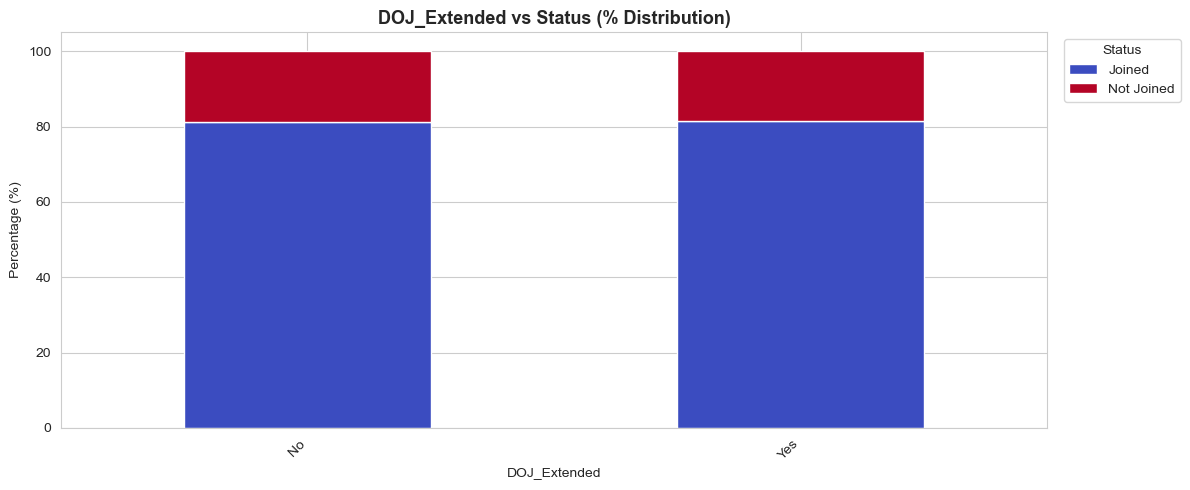

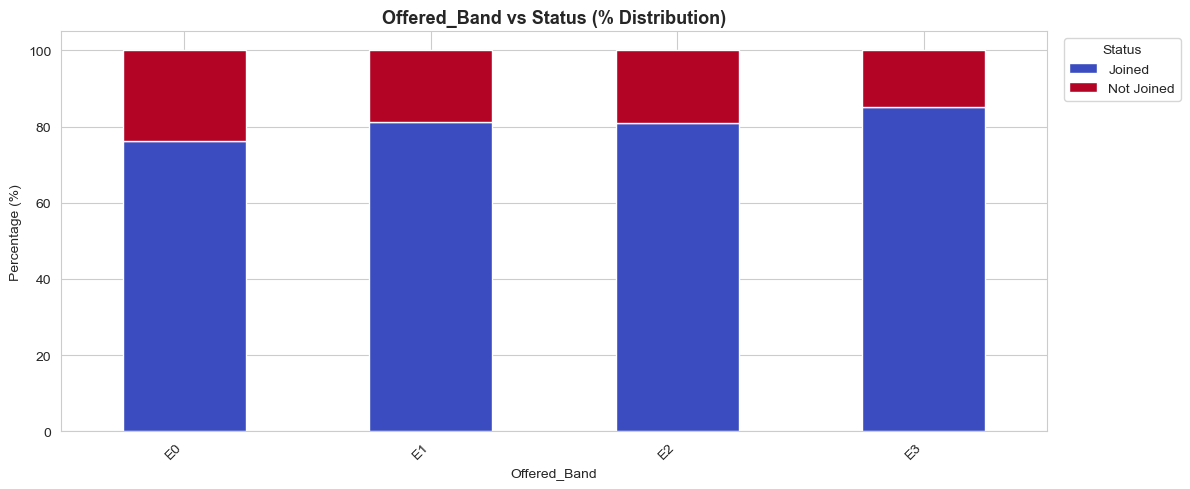

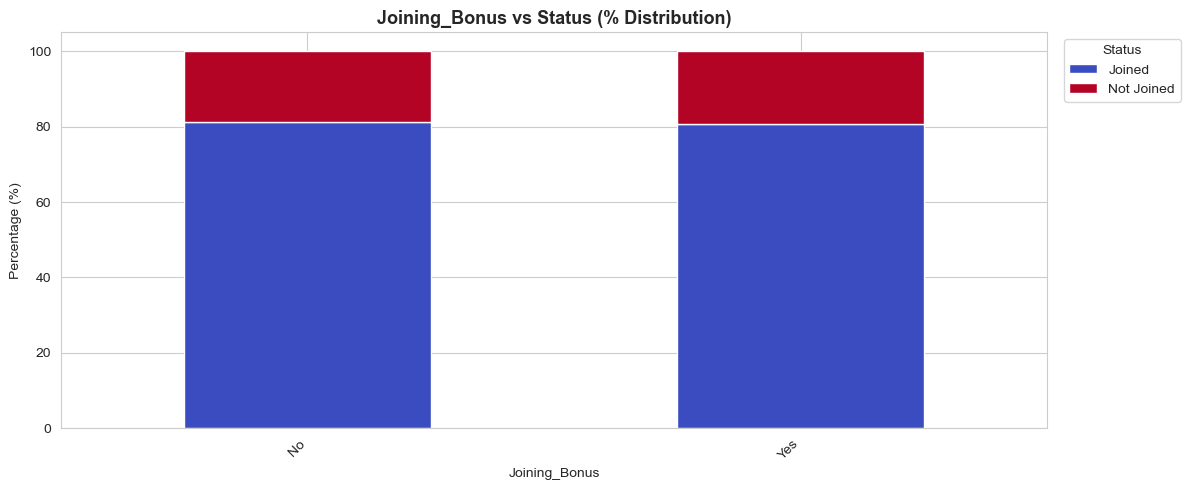

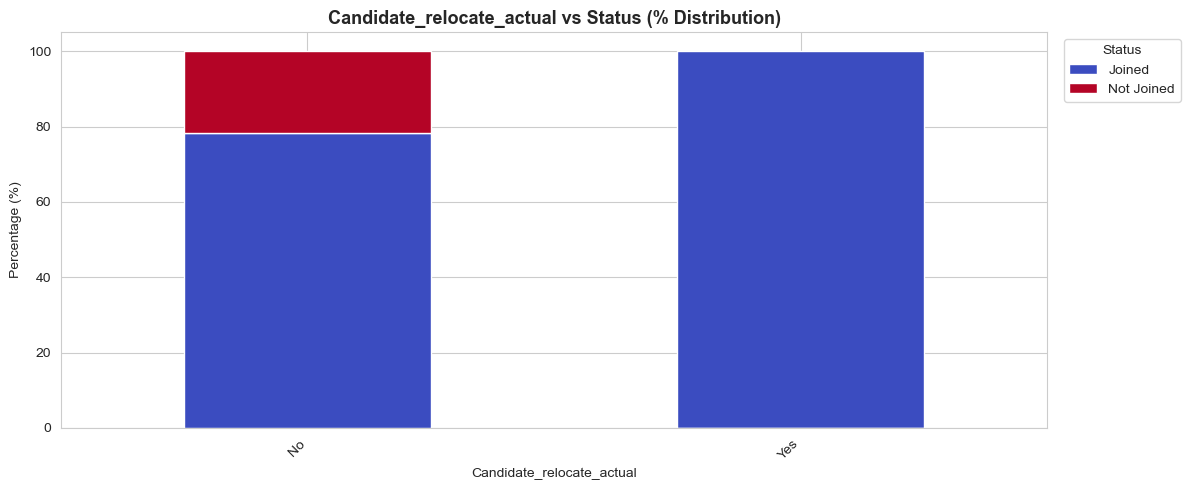

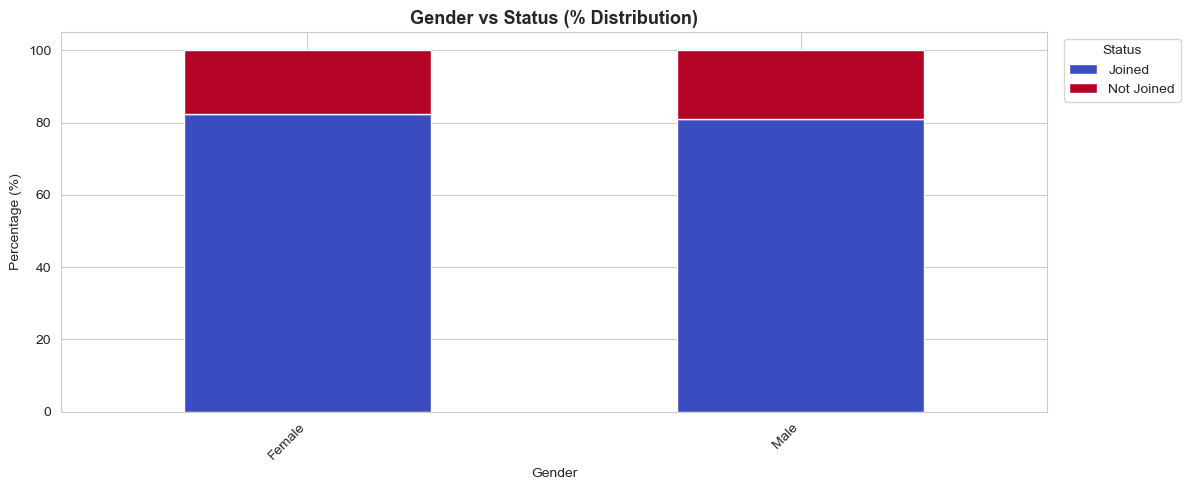

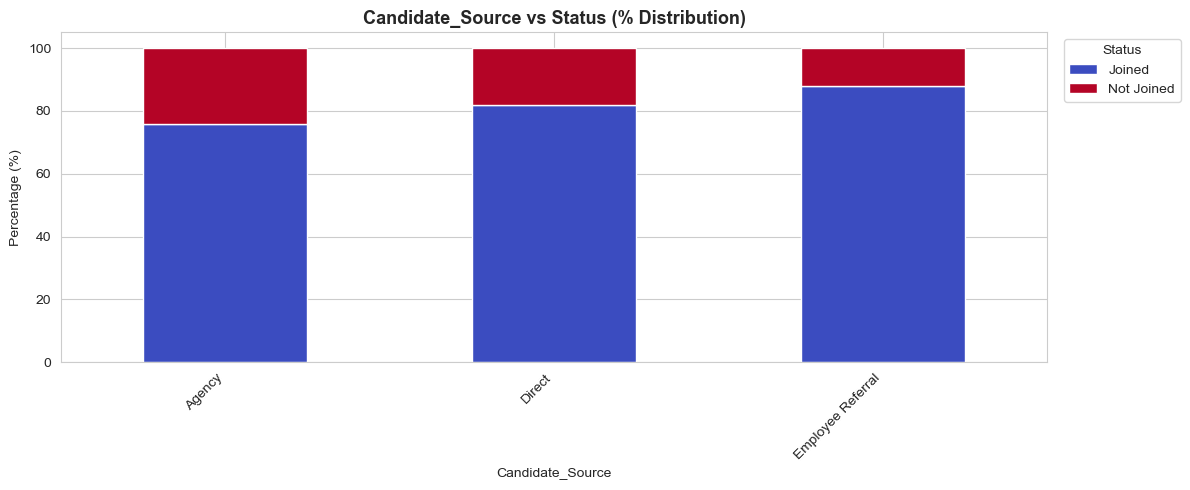

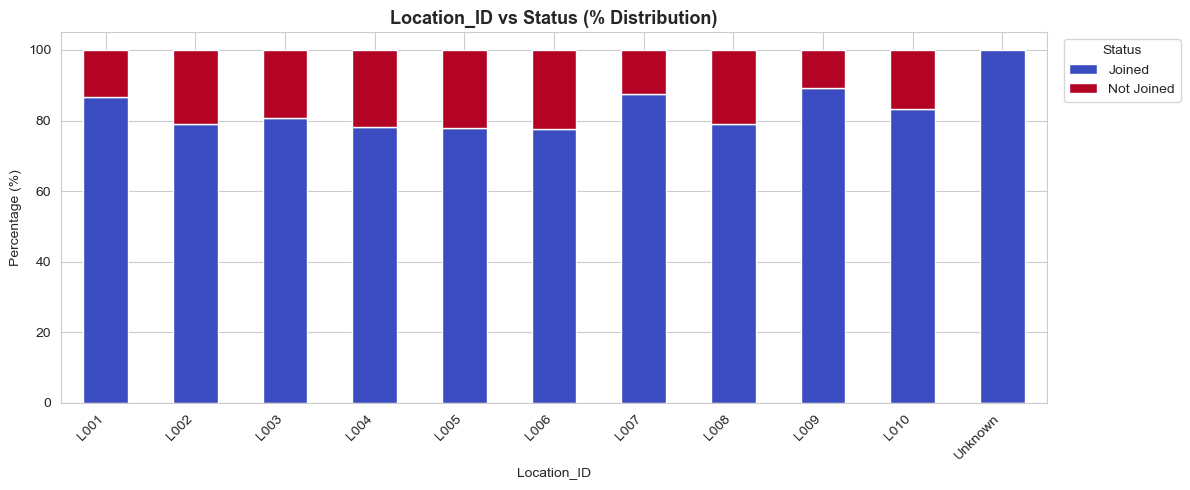

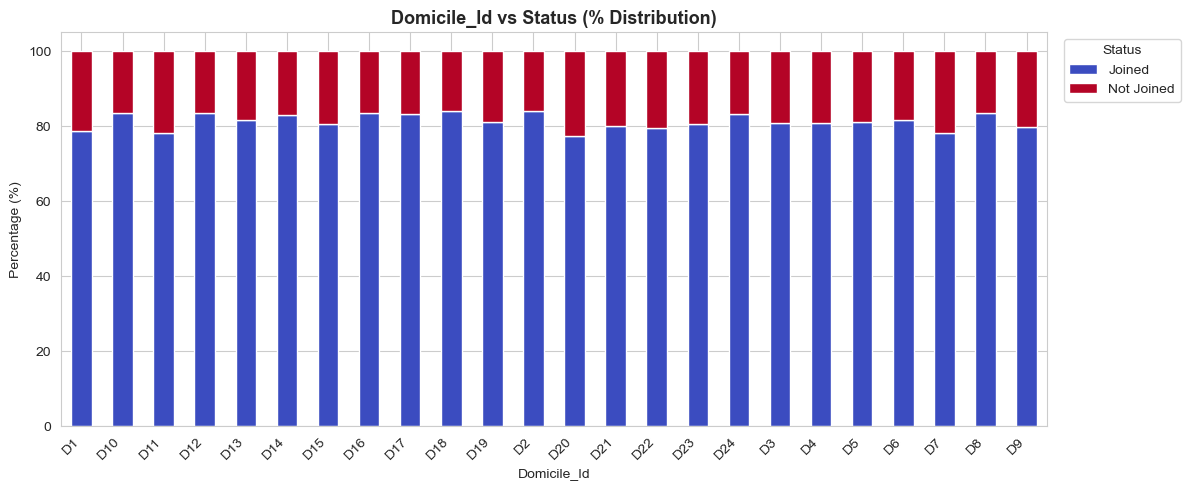

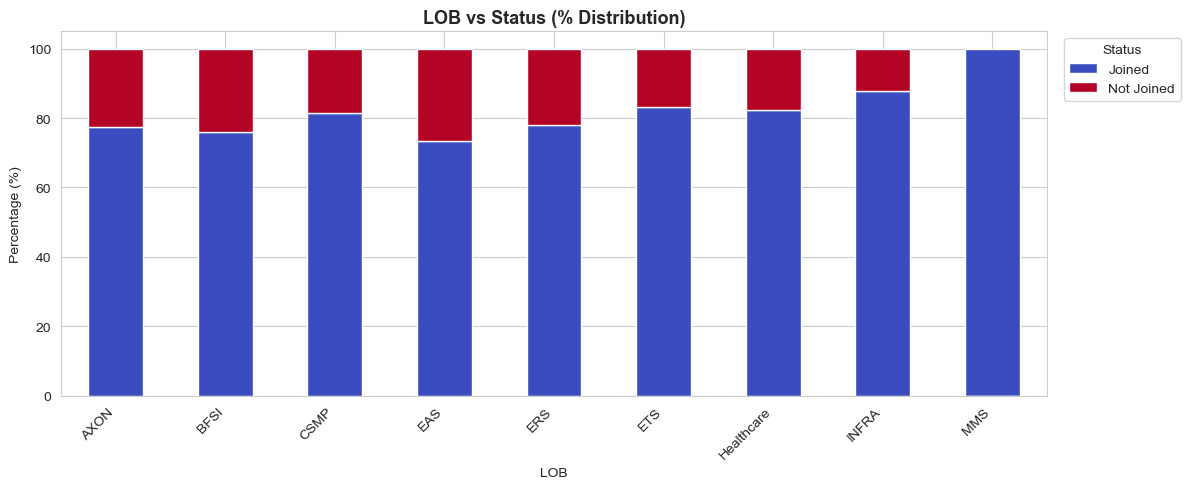

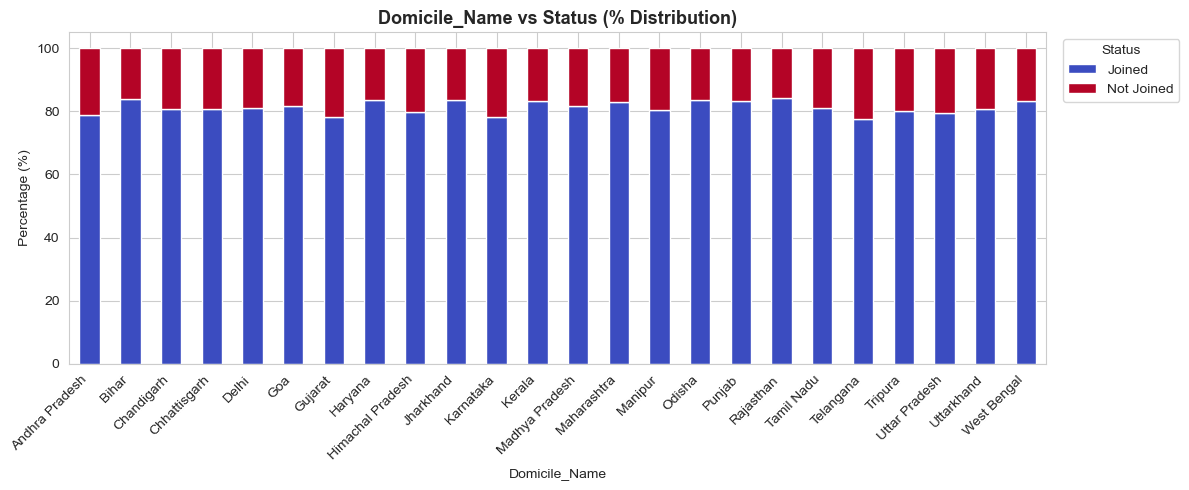

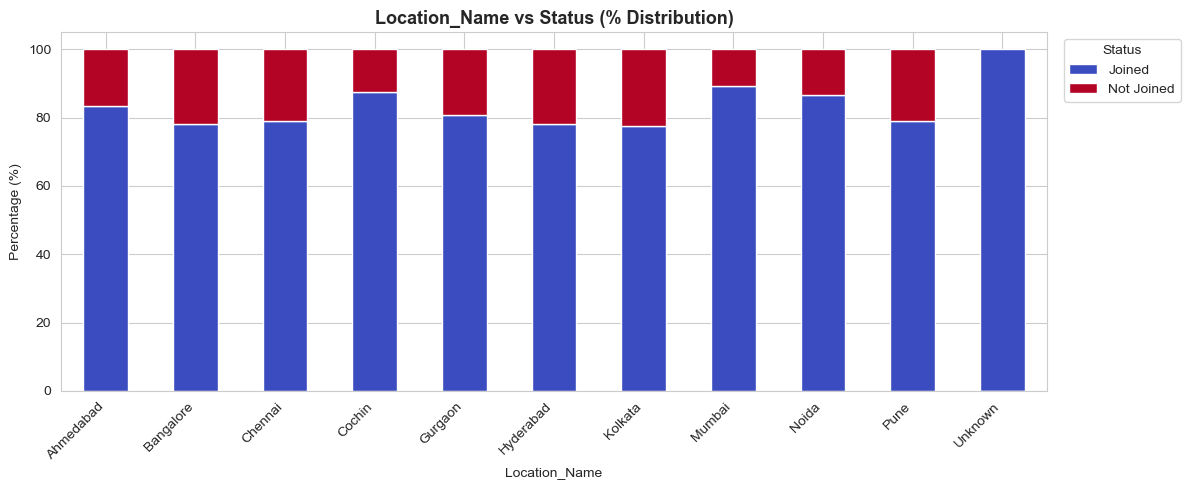

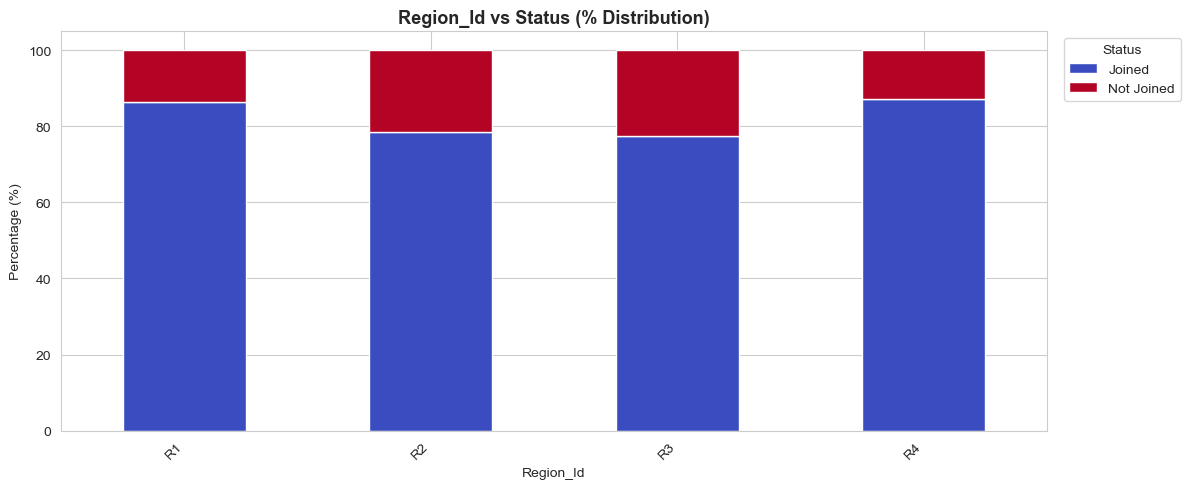

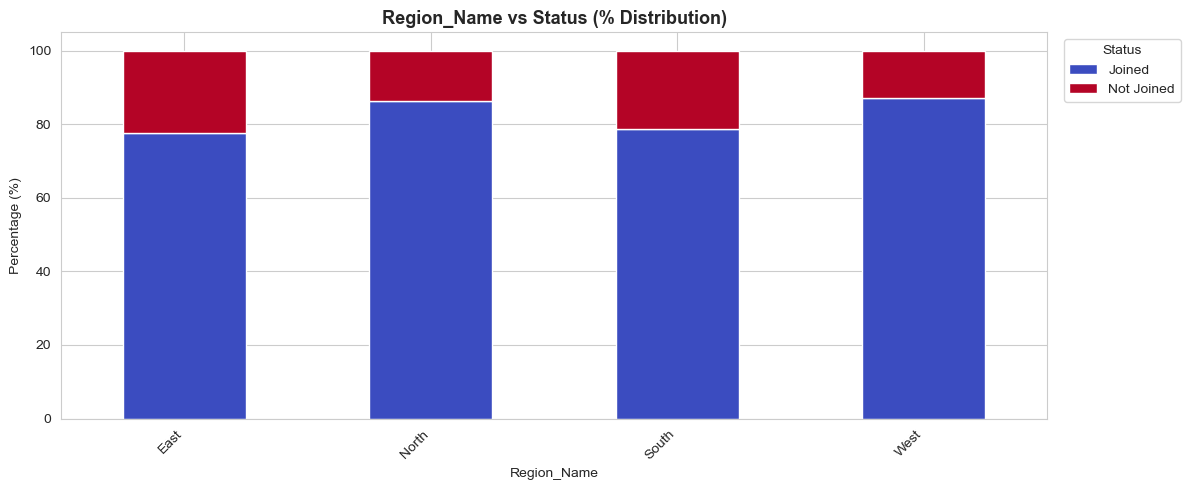

In [146]:
sns.set_style("whitegrid")
target = 'Status'

category_wo_status = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']

# 1. Categorical Feature vs Target (Stacked Bar Chart)
for col in category_wo_status:
    ct = pd.crosstab(data1[col], data1[target], normalize='index') * 100

    ct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='coolwarm', edgecolor='white')
    
    plt.title(f'{col} vs {target} (% Distribution)', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=target, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



# Insights from the Distribution Diagrams of Categorical Columns


1. *`DOJ_Extended`*

- No meaningful impact — joining rates are virtually identical whether DOJ was extended (81.55%) or not (81.08%), making this feature a near-zero signal for predicting Status



2. *`Offered_Band`*

- Higher band = higher joining rate — E3 leads at 85.26% while E0 lags at 76.30%, suggesting senior/better-compensated offers see less dropout
- E1 dominates volume (5578) but sits at an average 81.32% — the bulk of attrition risk lives here



3. *`Joining_Bonus`*

- Bonus has no effect — joining rates are nearly identical (81.34% No vs 80.58% Yes), meaning the bonus is not influencing candidates' final decision to join
- This feature can safely be deprioritized in any predictive model



4. *`Candidate_relocate_actual`*

- Relocation = guaranteed joining — 100% of the 1290 candidates who relocated actually joined, making this the strongest categorical signal in the entire dataset
- Non-relocators drop to 78.17%, confirming that physical relocation is the clearest commitment indicator



5. *`Gender`*

- Gender has negligible impact — Female (82.40%) and Male (81.07%) joining rates differ by barely 1.3 percentage points
- Not a useful predictor of Status, though gender diversity in sourcing remains a separate concern



7. *`Candidate_Source`*

- Employee Referrals are the highest quality source — 88% joining rate vs Agency's 75.82%, a 12-point gap that signals referrals bring more committed candidates
- Agency, being the costliest sourcing channel, also has the highest dropout — a clear ROI red flag



8. *`Location_ID`*

- Mumbai (L009: 89.34%) and Noida (L001: 86.62%) are the strongest joining locations — Kolkata (L006: 77.52%) and Hyderabad (L005: 78.01%) show the most dropout risk
- Top 3 locations drive 90% of volume, so their rates effectively define overall business performance



9. *`Domicile_Id / Domicile_Name`*

- Extremely narrow range — joining rates across all 24 states span only 77.45% (Telangana) to 84.05% (Rajasthan), a ~7-point band with no dramatic outliers
- Domicile is a weak predictor of Status; candidate's home state has little bearing on joining behavior



10. *`LOB`*

- INFRA is the standout performer at 87.79% joining rate while EAS (73.41%) and BFSI (75.86%) are the weakest — a 14-point spread making LOB one of the most discriminating features
- BFSI's high volume (1396) combined with a low joining rate makes it the single largest contributor to absolute dropout numbers



11. *`Location_Name`*

- Mumbai (89.34%) and Noida (86.62%) lead; Kolkata (77.52%) and Bangalore (78.12%) lag — despite Bangalore being the 3rd largest hub, it underperforms on joining rate
- Chennai, the highest volume city, sits at a below-average 78.92% — a high-priority location for dropout intervention



12. *`Region_Name`*

- North (86.32%) and West (87.25%) significantly outperform South (78.61%) and East (77.52%) — an ~9-point North-South gap is a major finding given South contributes 64% of all volume
- Most dropout risk is concentrated in the South region purely by scale — fixing South joining rates would move the overall needle the most

# Visual Representation of Numerical Columns vs Target (Status)

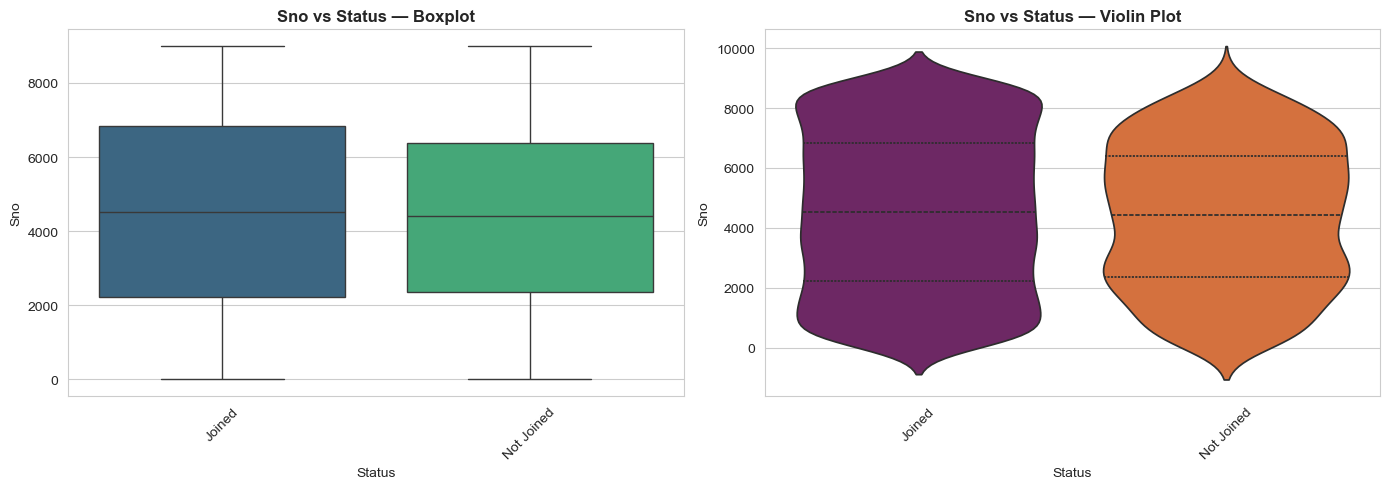

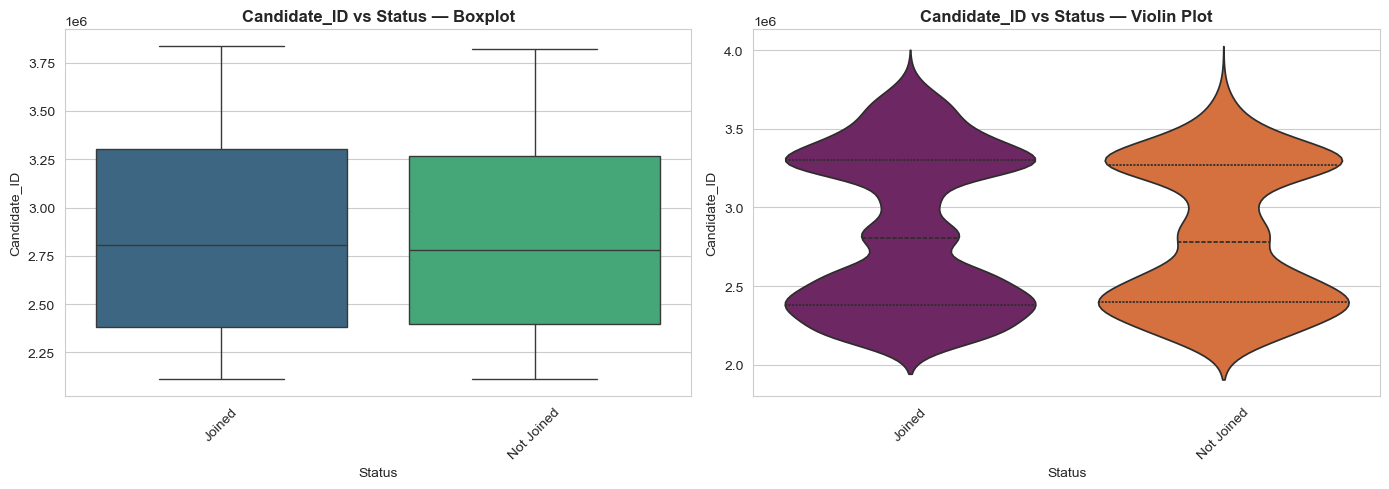

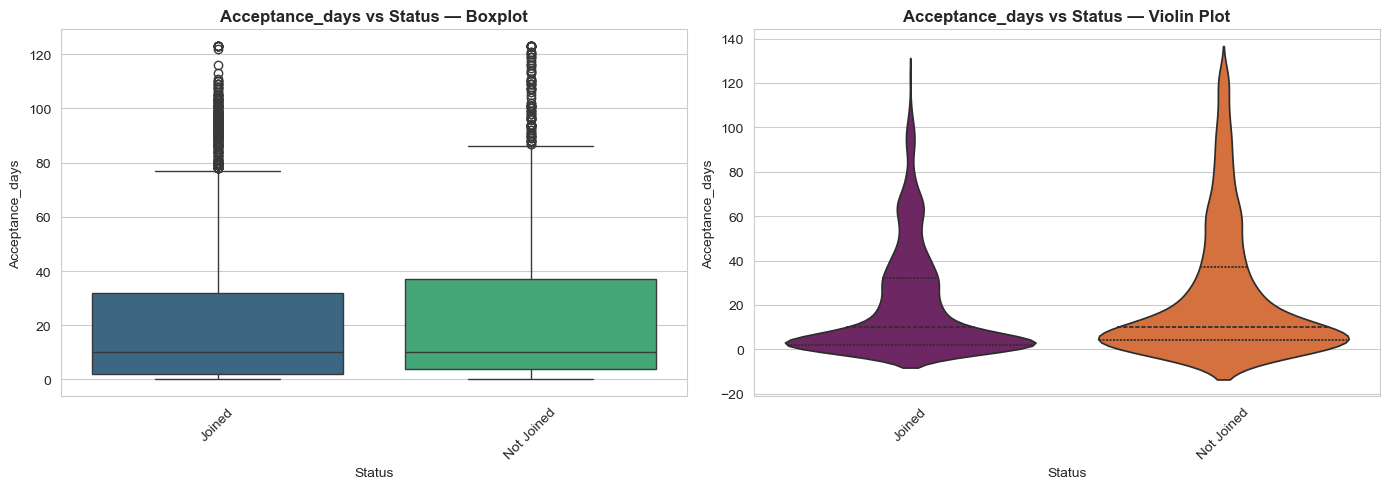

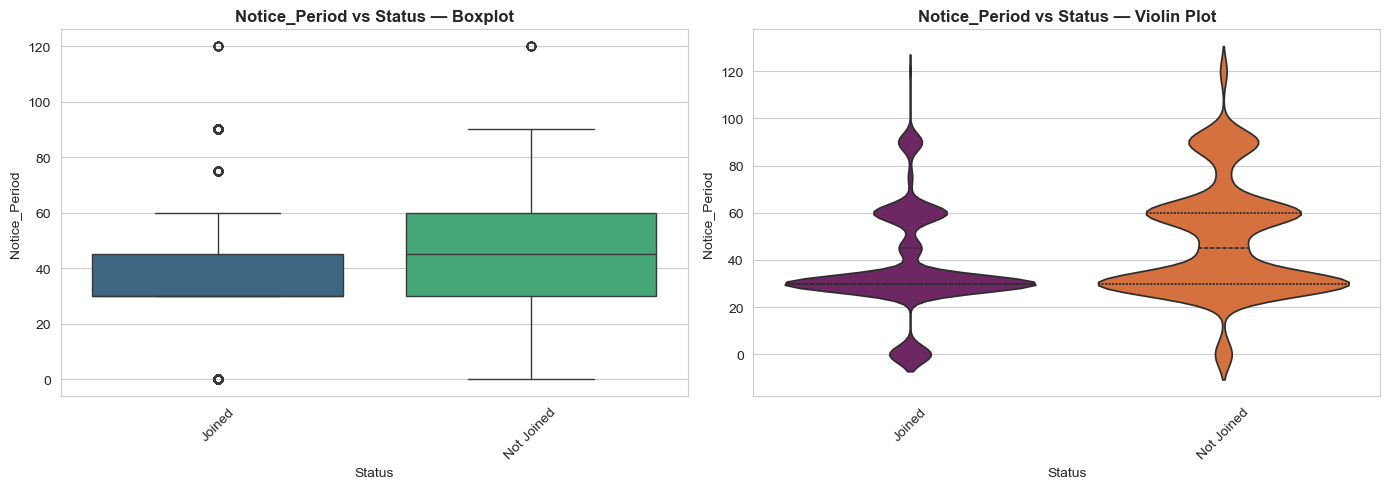

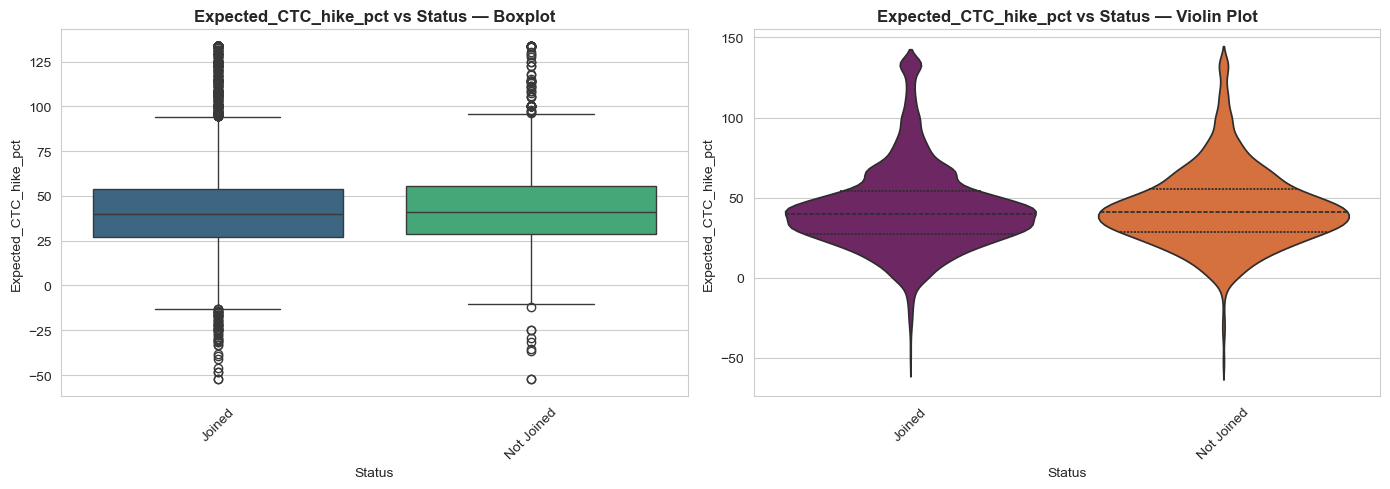

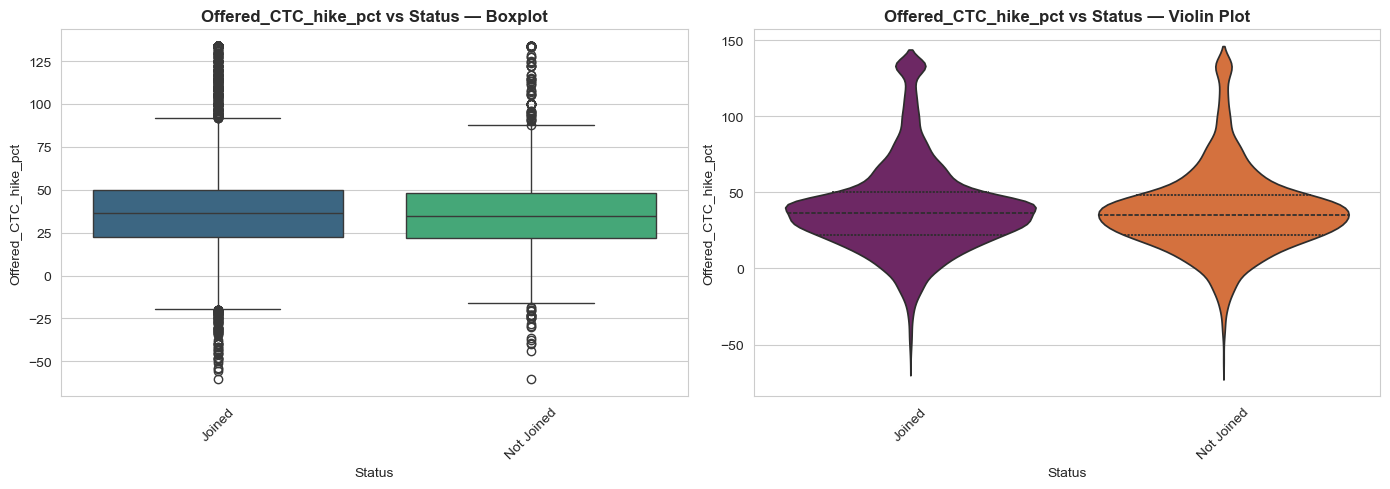

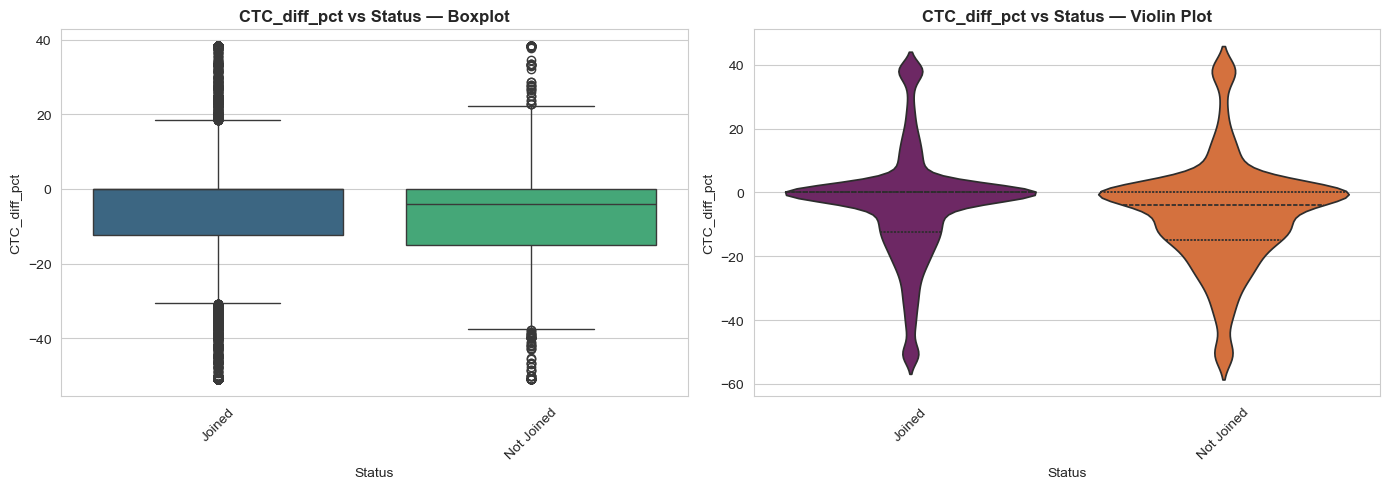

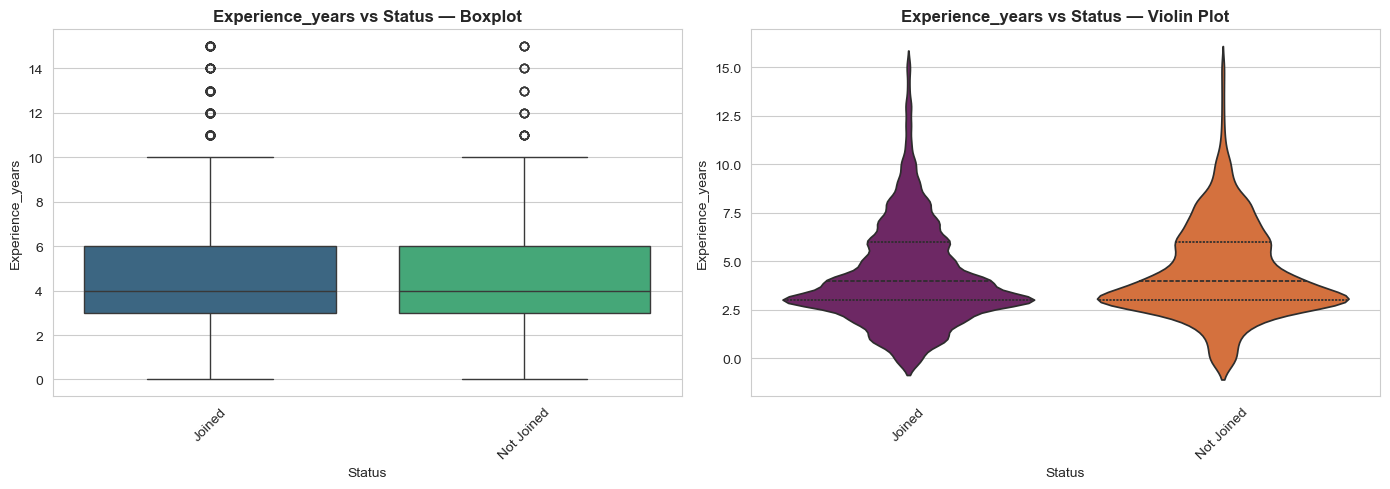

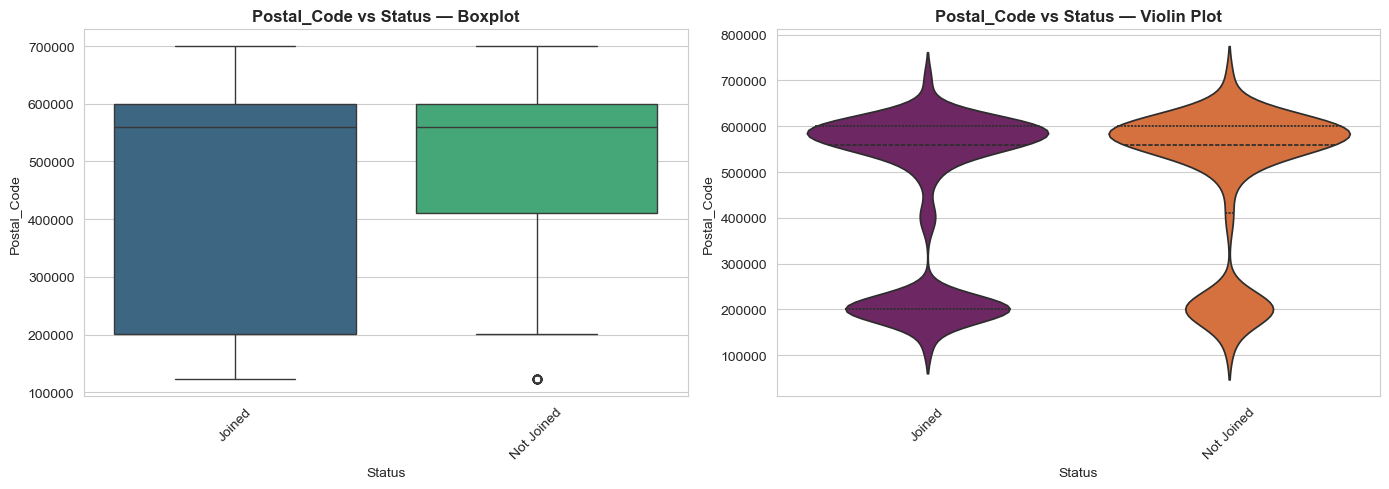

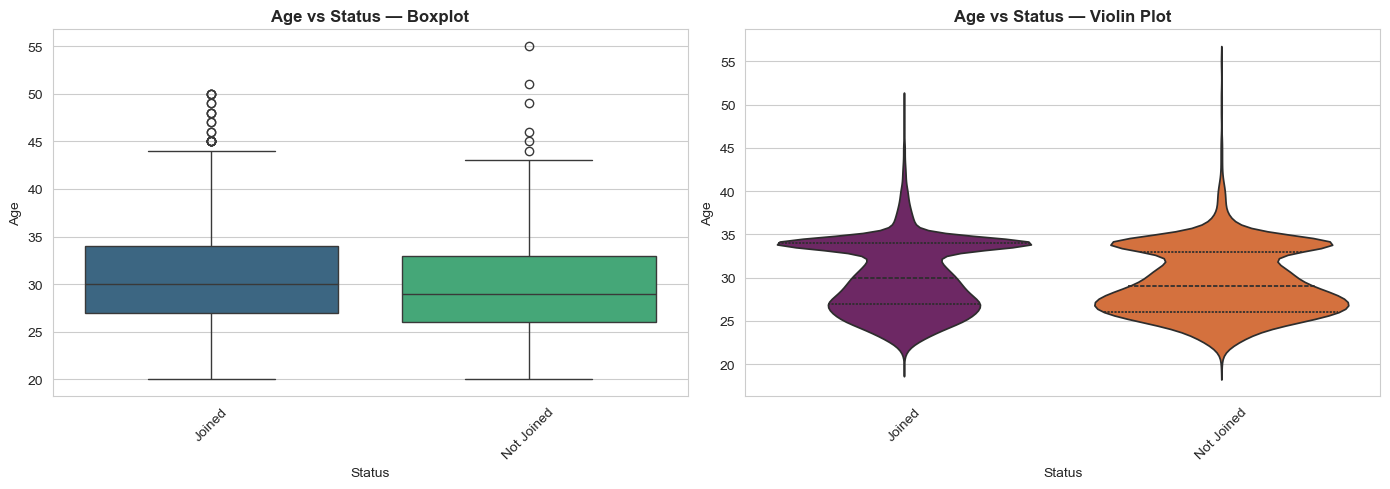

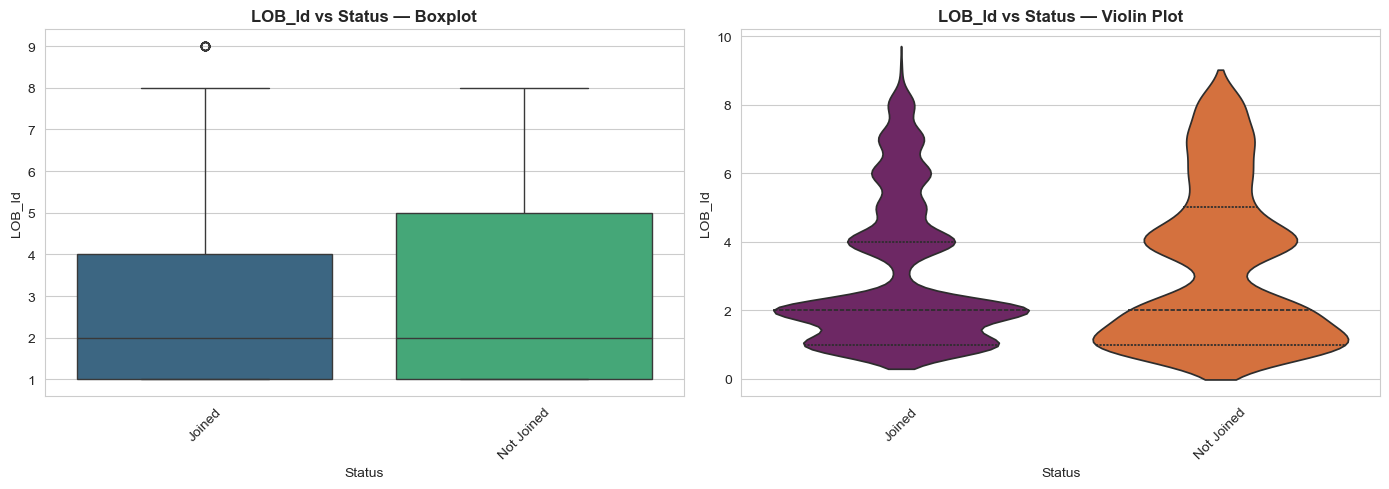

In [148]:
sns.set_style("whitegrid")

target = 'Status'

# 2. Numerical Feature vs Target (Boxplot + Violin Plot)
for col in numerical_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=data1, x=target, y=col, ax=axes[0], palette='viridis')
    
    axes[0].set_title(f'{col} vs {target} — Boxplot', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    sns.violinplot(data=data1, x=target, y=col, ax=axes[1], palette='inferno', inner='quartile')
    
    axes[1].set_title(f'{col} vs {target} — Violin Plot', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Insights from the Distribution Diagrams of Numerical Columns vs Target (Status)


1. *`Acceptance_days`*

- Not Joined candidates take longer to accept — mean of 24.76 days vs 20.62 for Joined, and Q3 is higher too (37 vs 32) — delay in acceptance is an early dropout signal
- Candidates who accept quickly are more likely to join.



2. *`Notice_Period`*

- Strongest numerical predictor of dropout — Not Joined mean is 48.19 days vs Joined's 37.24, with median 45 vs 30 — a full 15-day median gap
- Longer notice periods give candidates more time to receive counter-offers; high notice period = high dropout risk



3. *`Expected_CTC_hike_pct`*

- Near-identical distributions — Joined (43.06%) vs Not Joined (43.47%) — expected hike has zero discriminating power on joining outcome
- Both groups want similar hikes; the difference lies in what they were offered, not what they expected



4. *`Offered_CTC_hike_pct`*

- Marginal difference — Joined candidates received slightly higher offered hike (39.63%) vs Not Joined (37.67%), but the gap is small
- Not a strong standalone predictor, but combined with CTC_diff_pct it tells a richer story



5. *`CTC_diff_pct`*

- `Key financial signal` — Not Joined candidates have a larger negative gap vs Joined, meaning they were offered further below their expectation
- Candidates offered exactly at or above expectation almost always join



6. *`Experience_years`*

- Virtually no difference  — experience level does not predict joining behavior
- Can be deprioritized as a standalone feature; may have weak interaction effects with band or CTC



7. *`Age`*

- Negligible difference — Joined mean 30.00 vs Not Joined 29.51, almost identical distributions with same min/max range
- Age is not a predictor of Status in this dataset; drop from any predictive model

# task for tomorrow - 

1. Correlation and heatmap of Status vs rest columns
2. Insights and rest 4 questions from document.

BEFORE — data1 Status dtype  : object
BEFORE — data1 Status values : ['Joined' 'Not Joined']


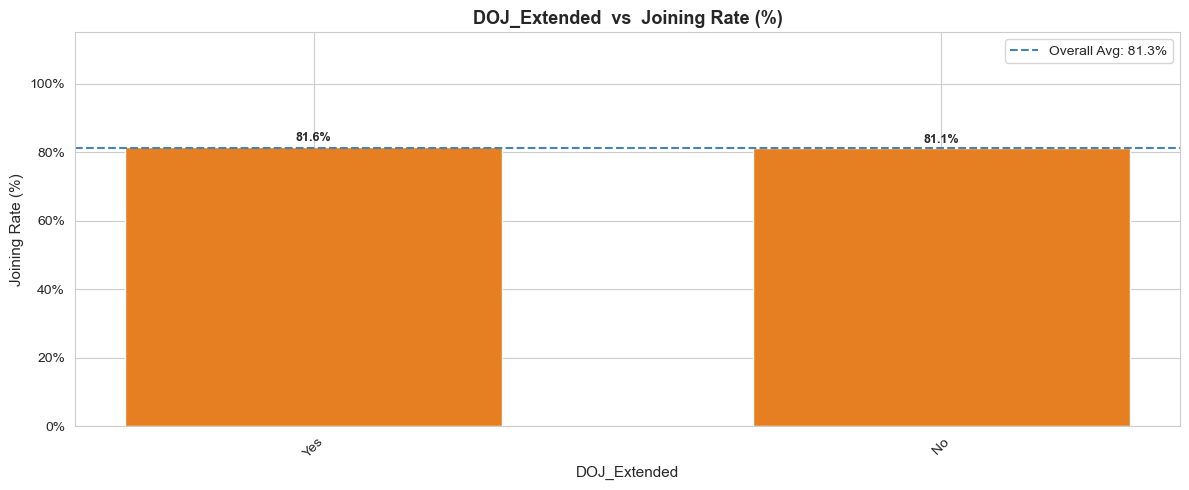

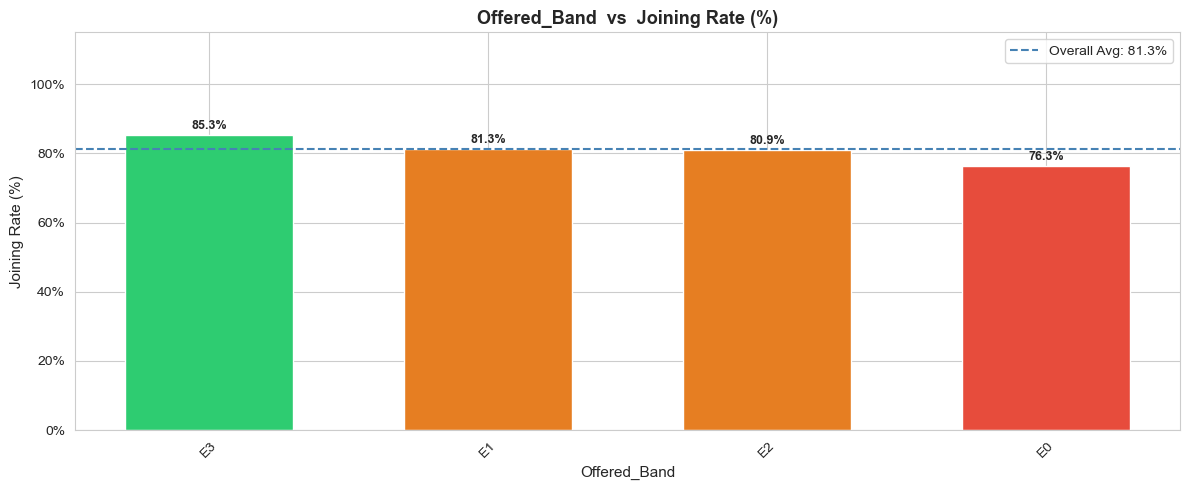

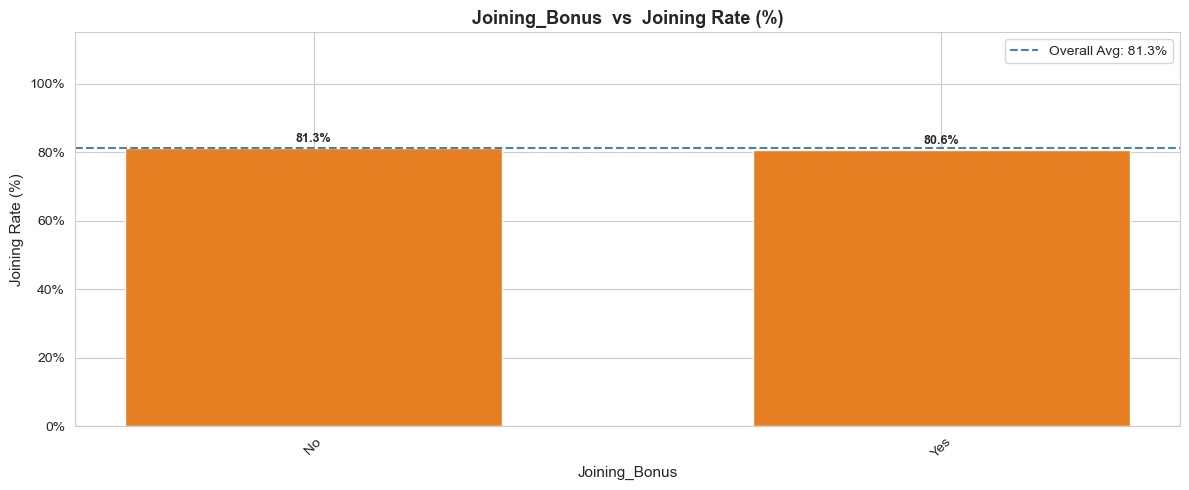

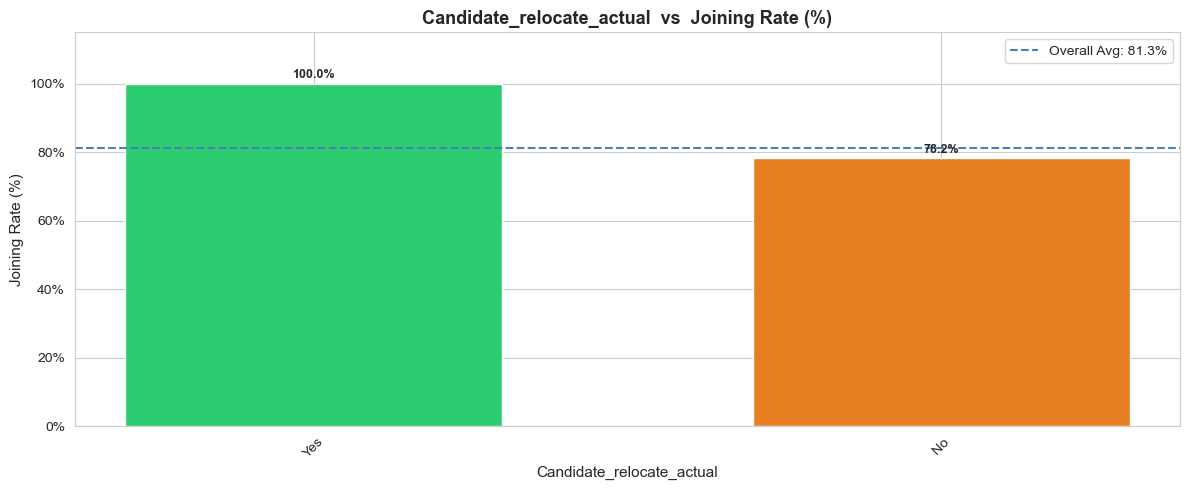

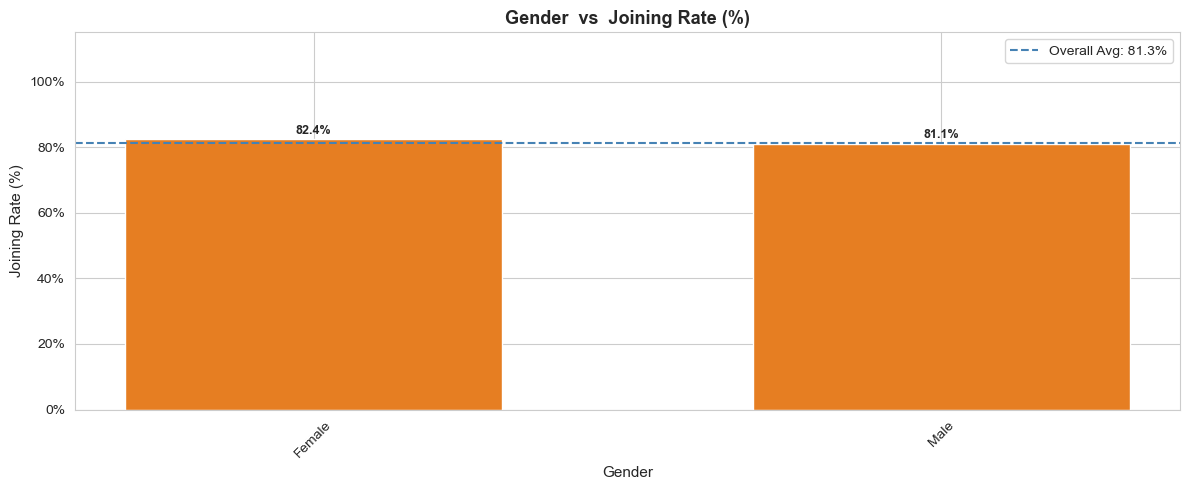

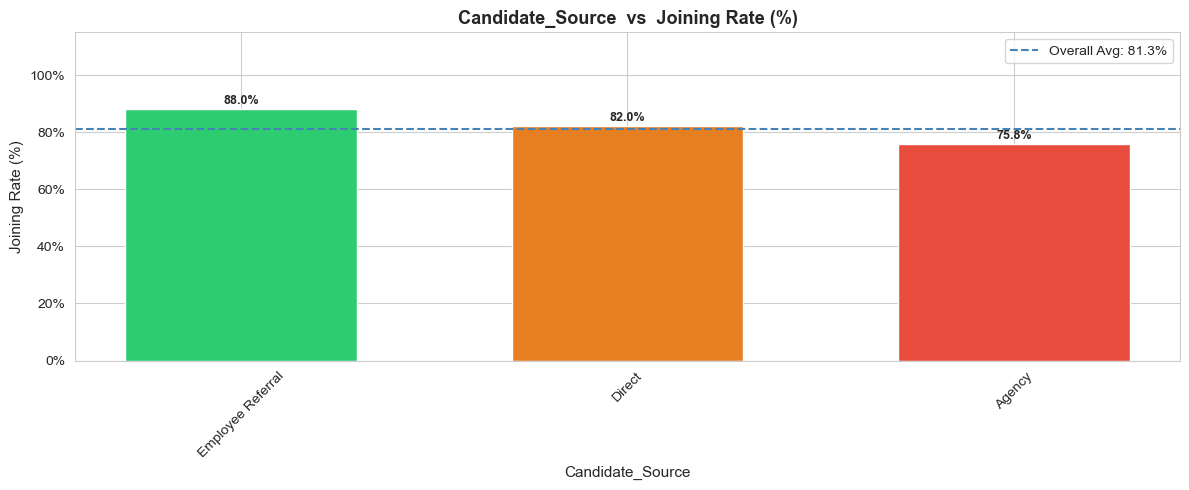

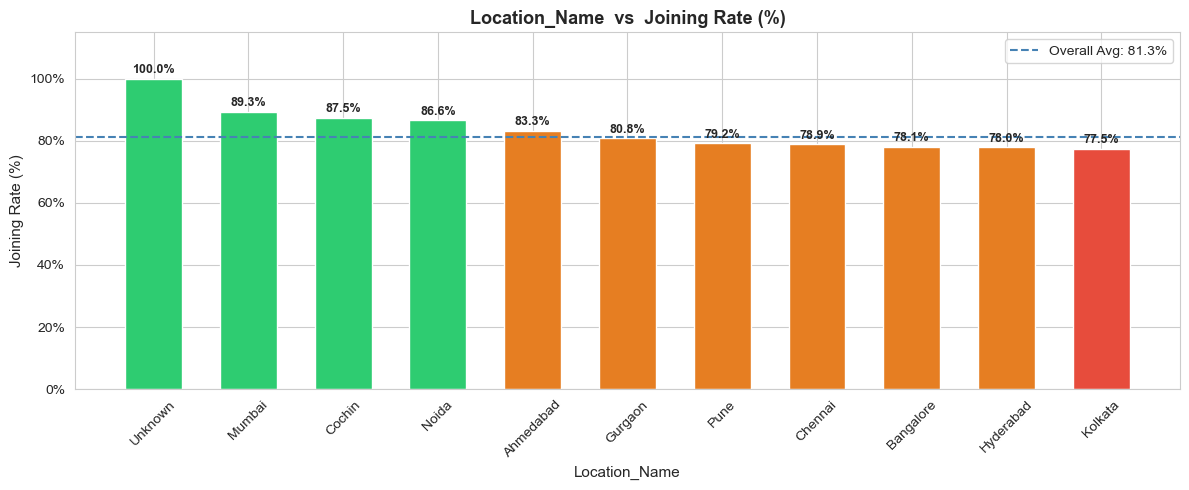

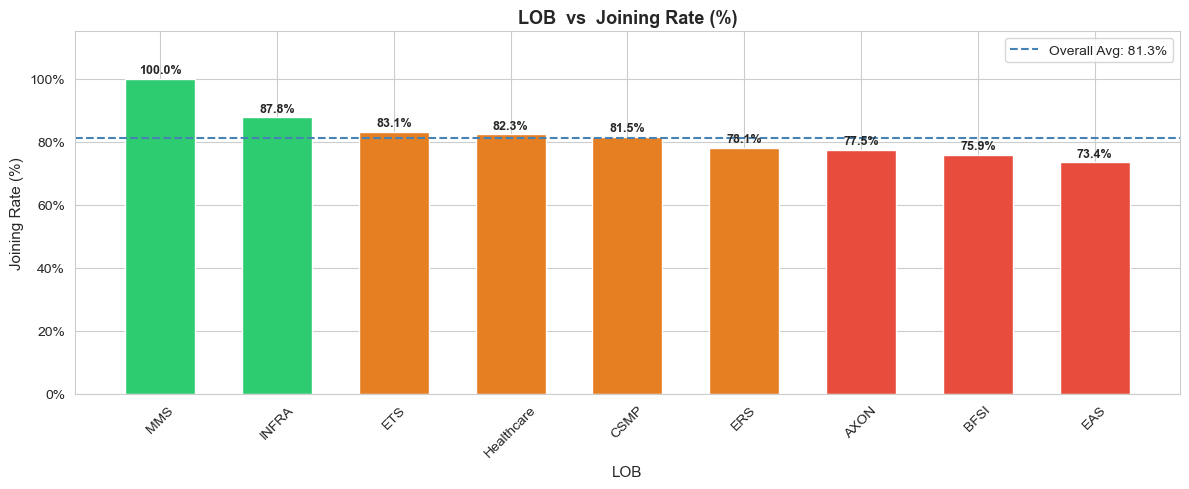

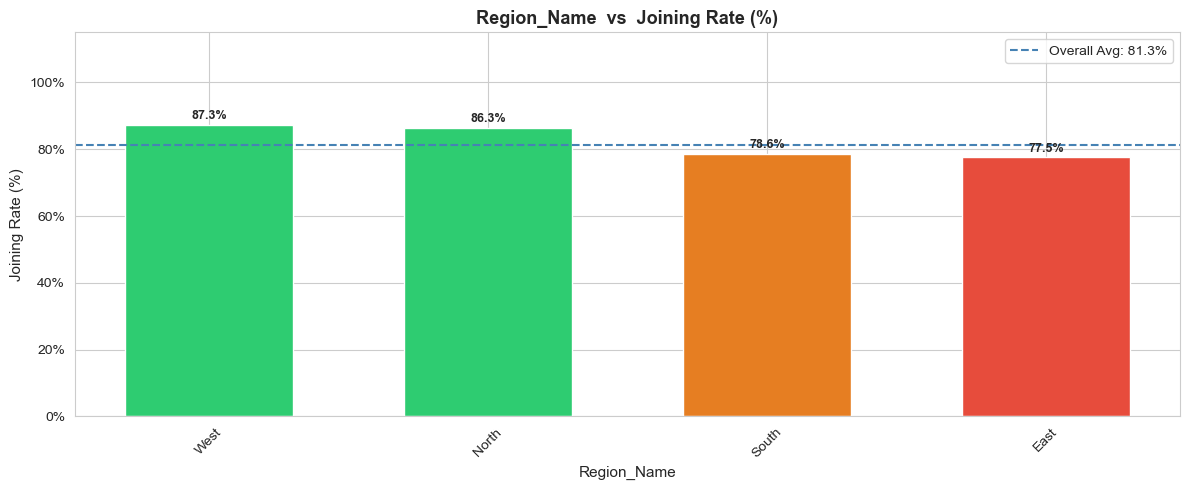

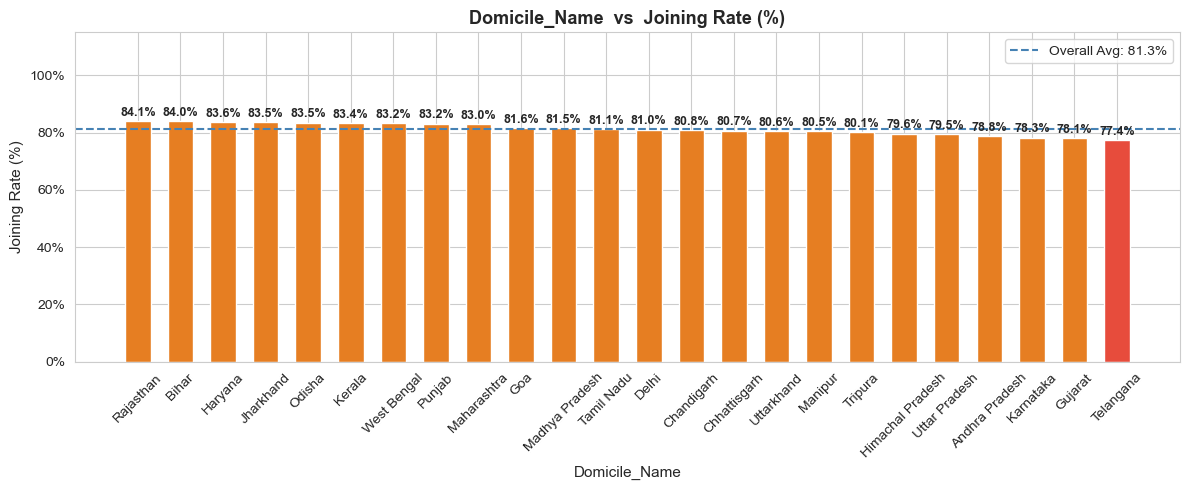


AFTER  — data1 Status dtype  : object
AFTER  — data1 Status values : ['Joined' 'Not Joined']
'Status_encoded' in data1    : False
data1 is completely unchanged!


In [159]:
sns.set_style("whitegrid")

target = 'Status'

categorical_columns = [
    'DOJ_Extended', 'Offered_Band', 'Joining_Bonus',
    'Candidate_relocate_actual', 'Gender', 'Candidate_Source',
    'Location_Name', 'LOB', 'Region_Name', 'Domicile_Name'
]

numerical_columns = [
    'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct',
    'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Age'
]

# Safety Check
print("BEFORE — data1 Status dtype  :", data1[target].dtype)
print("BEFORE — data1 Status values :", data1[target].unique())

# Temporary Copy (data1 is NEVER modified)
data_temp = data1.copy()
data_temp['Status_encoded'] = (data_temp[target] == 'Joined').astype(int)

# =============================================================================
# SECTION 1 — Categorical Columns vs Target (Joining Rate % Bar Chart)
# =============================================================================

for col in categorical_columns:

    # Calculate joining rate % per category
    join_rate = (
        data_temp.groupby(col)['Status_encoded']
        .mean() * 100
    ).reset_index()
    join_rate.columns = [col, 'Joining_Rate_%']
    join_rate = join_rate.sort_values('Joining_Rate_%', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))

    # Color: green if >= 85%, orange if >= 78%, red below
    bar_colors = [
        '#2ecc71' if v >= 85 else '#e67e22' if v >= 78 else '#e74c3c'
        for v in join_rate['Joining_Rate_%']
    ]

    bars = ax.bar(
        join_rate[col],
        join_rate['Joining_Rate_%'],
        color=bar_colors,
        edgecolor='white',
        width=0.6
    )

    # Overall average line
    overall_avg = data_temp['Status_encoded'].mean() * 100
    ax.axhline(
        overall_avg, color='steelblue',
        linestyle='--', linewidth=1.5,
        label=f'Overall Avg: {overall_avg:.1f}%'
    )

    # Value labels on top of bars
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 115)
    ax.set_title(f'{col}  vs  Joining Rate (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Joining Rate (%)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Final Safety Check
print("\nAFTER  — data1 Status dtype  :", data1[target].dtype)
print("AFTER  — data1 Status values :", data1[target].unique())
print("'Status_encoded' in data1    :", 'Status_encoded' in data1.columns)
print("data1 is completely unchanged!")


# Categorical Features importance and Relation with Target (Status)

# Feature ----- Importance ----- Score




Candidate_relocate_actual ----- Very High ----- 21.83% range


LOB ----- Very High ----- 26.59% range


Location_Name ----- High ----- 22.48% range


Candidate_Source ----- Moderate ----- 12.18% range


Region_Name ----- Moderate ----- 9.73% range


Offered_Band ----- Moderate ----- 8.96% range


Domicile_Name ----- Low ----- 6.61% range


Gender ----- Negligible ----- 1.33% range


Joining_Bonus ----- Negligible ----- 0.76% range


DOJ_Extended ----- Negligible ----- 0.48% range




Candidate_relocate_actual

Very High Importance — 21.83% range
Candidates willing to relocate have a 100% joining rate vs 78.17% for those who are not. Relocation willingness is the clearest indicator of candidate commitment in the entire dataset.

LOB

Very High Importance — 26.59% range
INFRA (87.79%) and ETS (83.07%) have the best joining rates while EAS (73.41%) and BFSI (75.86%) see the most dropouts. Business unit directly reflects market competition and role attractiveness.

Location_Name

High Importance — 22.48% range
Noida (86.62%) leads while Chennai (78.92%) and Bangalore (78.12%) — the two largest locations — fall below average. South India locations consistently underperform compared to North India locations.

Candidate_Source

Moderate Importance — 12.18% range
Employee Referrals (88%) outperform Agency hires (75.82%) by 12 percentage points. Referred candidates are more committed while agency candidates tend to hold multiple offers simultaneously.

Region_Name

Moderate Importance — 9.73% range
West (87.25%) and North (86.32%) significantly outperform South (78.61%) and East (77.52%). This feature largely mirrors Location_Name — consider dropping one to avoid redundancy in the model.

Offered_Band

Moderate Importance — 8.96% range
Clear trend — higher the band, higher the joining rate (E3: 85.26% down to E0: 76.30%). Suitable for ordinal encoding since the order is meaningful (E0=0, E1=1, E2=2, E3=3).

Domicile_Name

Low Importance — 6.61% range
Signal is diluted across 24 states with only 6.61% variation overall. Pattern aligns with Region_Name — consider grouping by region instead of keeping raw state values.

Gender

Negligible — 1.33% range
Female (82.40%) and Male (81.07%) joining rates are nearly identical. Gender has no meaningful influence on whether a candidate joins or not.

Joining_Bonus

Negligible — 0.76% range
Offering a joining bonus does not meaningfully increase the likelihood of joining (81.34% without vs 80.58% with). Counter-intuitive but the data clearly does not support this as a useful feature.

DOJ_Extended

Negligible — 0.48% range
Extending the date of joining has virtually zero impact on whether the candidate shows up (81.55% vs 81.08%). Safe to drop from the model.


# Numerical Columns Impoartance , Correlation plotting

In [156]:
num_with_target = numerical_columns + ['Status_encoded']


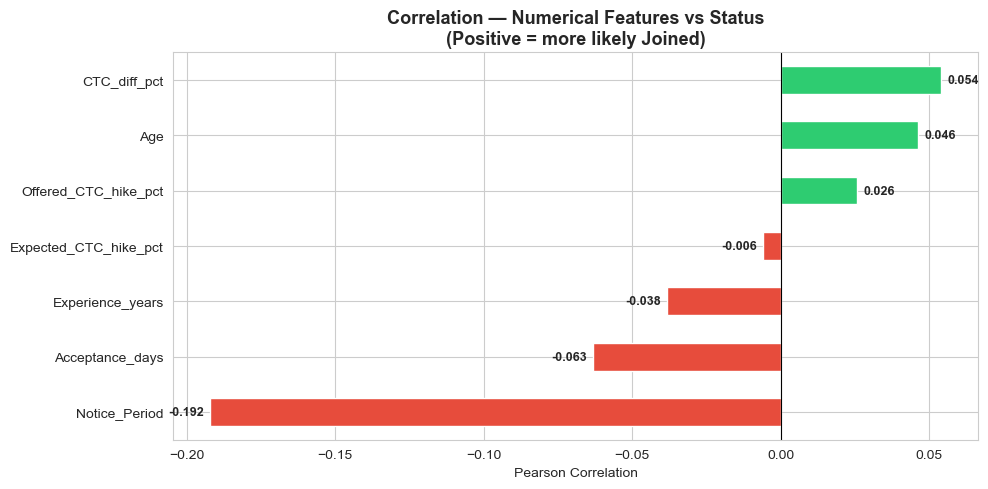

In [157]:
# Simple Correlation Bar Chart 

corr_with_target = (
    data_temp[num_with_target]
    .corr()['Status_encoded']
    .drop('Status_encoded')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(
    'Correlation — Numerical Features vs Status\n(Positive = more likely Joined)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Pearson Correlation')

# Value labels on bars
for i, (val, patch) in enumerate(zip(corr_with_target, ax.patches)):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        patch.get_y() + patch.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.show()


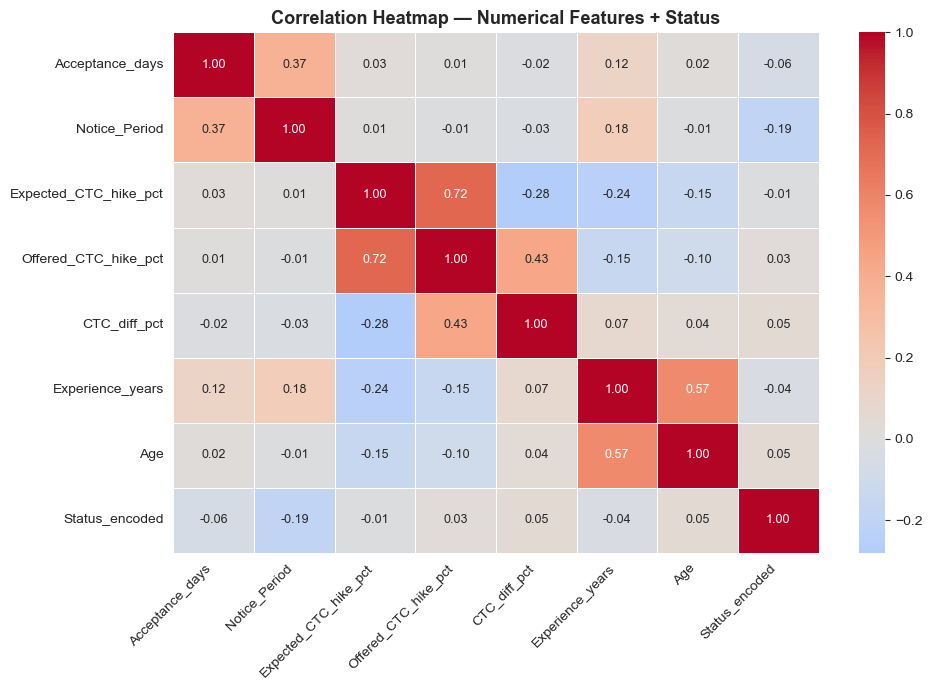

In [158]:
# Correlation Heatmap 

corr_matrix = data_temp[num_with_target].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 9}
)

ax.set_title(
    'Correlation Heatmap — Numerical Features + Status',
    fontsize=13, fontweight='bold'
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Numerical Columns Importance and Correlation with Target (Status)

## Feature ----- Importance ----- Correlation 




Notice_Period ----- High ----- `-0.19 `


Acceptance_days ----- Low ----- `-0.06`



CTC_diff_pct ----- Low ----- `0.05`



Age ----- Very Low ----- `0.05`



Experience_years ----- Very Low ----- `-0.04`



Offered_CTC_hike_pct ----- Negligible ----- `0.03`


Expected_CTC_hike_pct ----- Drop ----- `-0.006`

Notice_Period

High Importance — Correlation: -0.19 
Dropouts have an average notice period of 48.19 days vs 37.24 days for joiners. Longer notice period gives the current employer more time to make a counter-offer, significantly increasing dropout risk.

Acceptance_days

Low Importance — Correlation: -0.06
Joiners accepted offers in 20.62 days vs 24.76 days for dropouts. Directionally consistent — faster acceptance signals stronger intent — but the signal is too weak to rely on independently.

CTC_diff_pct

Low Importance — Correlation: 0.05 
Joiners have a smaller gap between expected and offered CTC (-4.34%) vs non-joiners (-6.71%). Weak but logical — the closer the offer is to expectations, the more likely the candidate joins.

Age

Very Low Importance — Correlation: 0.05 
Mean age is nearly identical — 30.00 years for joiners vs 29.51 years for non-joiners. No meaningful predictive value on its own.

Experience_years

Very Low Importance — Correlation: -0.04 
Mean experience is almost the same — 4.19 years for joiners vs 4.43 years for non-joiners. Very weak signal, low priority for the model.

Offered_CTC_hike_pct

Negligible — Correlation: 0.03 
Despite intuition, a higher offered hike does not strongly drive joining. The mean difference of just 1.96% between the two groups makes this a very unreliable predictor.

Expected_CTC_hike_pct

Drop — Correlation: -0.006 
Near-zero correlation and a negligible mean difference. What a candidate expects has no bearing on joining — this is already better captured by CTC_diff_pct, making this feature redundant.

## Done!!!!!!!!!

#### Q. Analysis of percentage joined of offer released.
Out of a total of 8,995 candidates who received offers, approximately 81.3% joined and 18.7% did not join. This means roughly 1 in 5 candidates who received an offer dropped out before joining. While an 81% joining rate appears healthy on the surface, the dropout rate of nearly 19% represents a significant recruitment loss — especially given the effort and cost involved in extending an offer.

#### Q. What are the key drivers that influence the candidate joining/not joining a company?
The following features have the strongest influence on joining behavior:



Driver
Type
Key Finding




Candidate_relocate_actual
Categorical
100% joining if willing to relocate vs 78.17% if not


LOB
Categorical
26.59% range — INFRA joins most, EAS joins least


Notice_Period
Numerical
Dropouts have 11 more days of notice on average


Location_Name
Categorical
22.48% range — North outperforms South consistently


Candidate_Source
Categorical
Referrals (88%) vs Agency (75.82%) — 12% gap


Offered_Band
Categorical
Higher band = higher joining rate, clear monotonic trend



Relocation willingness, business unit, notice period, and sourcing channel are the four most actionable levers. Candidates from agency channels with long notice periods in South India LOBs like EAS and BFSI represent the highest dropout risk profile.

#### Q. Are there specific locations where candidates are not joining?
Yes. The data shows a clear geographic pattern in dropout behavior.



Location
Joining Rate
Volume




Noida
86.62%
2727


Mumbai
89.34%
197


Gurgaon
80.82%
146


Pune
79.17%
48


Chennai
78.92%
3150


Bangalore
78.12%
2230


Hyderabad
78.01%
341


Kolkata
77.52%
129



Chennai and Bangalore are the most critical concern — they are the two largest hiring locations but both sit below the overall average joining rate. Hyderabad and Kolkata also underperform. The pattern is consistent — South India locations have structurally lower joining rates, likely driven by higher market competition and more counter-offer activity in these tech hubs.

#### Q. Joining status depends on the duration to accept an offer?
There is a weak but consistent relationship between acceptance duration and joining behavior.



Group
Mean Acceptance Days




Joined
20.62 days


Not Joined
24.76 days


Difference
4.14 days



Candidates who did not join took about 4 days longer to accept the offer compared to those who joined. Pearson correlation is -0.063, which is statistically weak. The direction is intuitive — faster acceptance reflects stronger intent — but this feature alone is not a reliable predictor. It works better as a supporting signal alongside Notice_Period and Candidate_Source rather than as a standalone driver.

#### Q. Hike offered has an impact on joining status?
The data suggests that hike offered has a minimal impact on joining behavior.



Group
Mean Offered Hike




Joined
39.63%


Not Joined
37.67%


Difference
1.96%



Pearson correlation is only 0.026, which is negligible. Despite the common assumption that a higher hike drives joining, the data does not support this strongly. However, CTC_diff_pct — which measures the gap between what was offered and what the candidate expected — is a better and more meaningful signal (correlation: 0.05, mean difference: 2.37%). This suggests that it is not the absolute hike that matters, but how close the offer is to the candidate's expectation. Candidates are more likely to join when the offer meets or nearly meets their expected CTC rather than when the hike percentage is simply high.